# Prédiction de la consommation électrique - Brief Time Series

Ce notebook présente l'exploration des données de consommation électrique issues de l'API ODRÉ, dans le cadre du brief sur la prédiction de consommation électrique et la détection d'anomalies.

# Plan global du notebook

Ce notebook est organisé en plusieurs grandes parties :

1. Consommation ODRÉ, EDA et approche univariée
2. Modèles classiques de séries temporelles : ARIMA, auto-ARIMA, SARIMA et TBATS
3. Enrichissement multivarié : météo Open-Meteo et calendrier
4. Modèles avancés : LSTM et modèles de fondation
5. Détection d'anomalies : Isolation Forest et SHAP
6. Interface utilisateur : Streamlit ou Gradio

# Partie 1 — Consommation ODRÉ, EDA et approche univariée

Cette partie prépare les données de consommation électrique issues de l'API ODRÉ pour Brest Métropole.

Elle comprend la récupération des données, le passage à une granularité journalière, le contrôle qualité, la création des séries temporelles, une première baseline univariée et l'analyse exploratoire de la série.

## A — Accès aux données ODRÉ et cadrage du périmètre

Sections 1 à 9

API, Brest Métropole, fichiers bruts, moyenne journalière.

## 1. Import des bibliothèques

Chargement des bibliothèques nécessaires pour la récupération des données, leur manipulation et les premiers affichages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

print("pandas :", pd.__version__)
print("numpy :", np.__version__)
print("Environnement OK")

pandas : 3.0.3
numpy : 2.4.6
Environnement OK


## 2. Test de connexion à l'API ODRÉ

Vérification du bon fonctionnement de l'API ODRÉ et de l'accès au jeu de données de consommation électrique des métropoles.

In [2]:
import requests
import pandas as pd

url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-metropoles-tr/records"

params = {
    "limit": 5
}

response = requests.get(url, params=params)

print("Statut :", response.status_code)

data = response.json()
data

Statut : 200


{'total_count': 4729068,
 'results': [{'code_insee_epci': '200054807',
   'libelle_metropole': "Métropole d'Aix-Marseille-Provence",
   'nature': 'Données temps réel',
   'date': '2020-03-19',
   'heures': '04:00',
   'date_heure': '2020-03-19T03:00:00+00:00',
   'consommation': 1322,
   'production': None,
   'echanges_physiques': None},
  {'code_insee_epci': '200054807',
   'libelle_metropole': "Métropole d'Aix-Marseille-Provence",
   'nature': 'Données temps réel',
   'date': '2020-03-19',
   'heures': '04:15',
   'date_heure': '2020-03-19T03:15:00+00:00',
   'consommation': 1321,
   'production': None,
   'echanges_physiques': None},
  {'code_insee_epci': '200054807',
   'libelle_metropole': "Métropole d'Aix-Marseille-Provence",
   'nature': 'Données temps réel',
   'date': '2020-03-19',
   'heures': '06:15',
   'date_heure': '2020-03-19T05:15:00+00:00',
   'consommation': 1461,
   'production': None,
   'echanges_physiques': None},
  {'code_insee_epci': '200054807',
   'libelle_me

## 3. Exploration de la structure de la réponse API

Identification des informations disponibles dans la réponse renvoyée par l'API ODRÉ.

In [3]:
# Affichage des clés principales de la réponse API
data.keys()

dict_keys(['total_count', 'results'])

## 4. Transformation de la réponse API en tableau

Conversion des premiers résultats renvoyés par l'API ODRÉ en DataFrame pandas afin de faciliter l'analyse des données.

In [4]:
df_test = pd.DataFrame(data["results"])

df_test

,code_insee_epci,libelle_metropole,nature,date,heures,date_heure,consommation,production,echanges_physiques
0,200054807,Métropole d'Aix-Marseille-Provence,Données temps réel,2020-03-19,04:00,2020-03-19T03:00:00+00:00,1322,None,None
1,200054807,Métropole d'Aix-Marseille-Provence,Données temps réel,2020-03-19,04:15,2020-03-19T03:15:00+00:00,1321,None,None
2,200054807,Métropole d'Aix-Marseille-Provence,Données temps réel,2020-03-19,06:15,2020-03-19T05:15:00+00:00,1461,None,None
3,200054807,Métropole d'Aix-Marseille-Provence,Données temps réel,2020-03-19,06:45,2020-03-19T05:45:00+00:00,1419,None,None
4,200054807,Métropole d'Aix-Marseille-Provence,Données temps réel,2020-03-19,07:45,2020-03-19T06:45:00+00:00,1446,None,None


In [5]:
df_test.columns

Index(['code_insee_epci', 'libelle_metropole', 'nature', 'date', 'heures',
       'date_heure', 'consommation', 'production', 'echanges_physiques'],
      dtype='str')

## 5. Identification des métropoles disponibles

Extraction de la liste des métropoles présentes dans le jeu de données afin d'identifier le libellé exact correspondant à Brest Métropole.

In [6]:
params = {
    "select": "libelle_metropole",
    "group_by": "libelle_metropole",
    "limit": 100
}

response = requests.get(url, params=params)

print("Statut :", response.status_code)

data_metropoles = response.json()
df_metropoles = pd.DataFrame(data_metropoles["results"])

df_metropoles

Statut : 200


,libelle_metropole
0,Bordeaux Métropole
1,Brest Métropole
2,Clermont Auvergne Métropole
3,Dijon Métropole
4,Eurométropole de Strasbourg
5,Montpellier Méditerranée Métropole
6,Métropole Européenne de Lille
7,Métropole Grenoble-Alpes-Métropole
8,Métropole Nice Côte d'Azur
9,Métropole Rennes Métropole


## 6. Récupération des premières données de Brest Métropole

Extraction d'un échantillon de données de consommation électrique pour Brest Métropole à partir du jeu de données ODRÉ.

In [7]:
params = {
    "where": "libelle_metropole = 'Brest Métropole'",
    "order_by": "date_heure ASC",
    "limit": 10
}

response = requests.get(url, params=params)

print("Statut :", response.status_code)

data_brest = response.json()
df_brest_test = pd.DataFrame(data_brest["results"])

df_brest_test

Statut : 200


,code_insee_epci,libelle_metropole,nature,date,heures,date_heure,consommation,production,echanges_physiques
0,242900314,Brest Métropole,Données temps réel,2020-01-01,01:00,2020-01-01T00:00:00+00:00,106,None,None
1,242900314,Brest Métropole,Données temps réel,2020-01-01,01:15,2020-01-01T00:15:00+00:00,108,None,None
2,242900314,Brest Métropole,Données temps réel,2020-01-01,01:30,2020-01-01T00:30:00+00:00,113,None,None
3,242900314,Brest Métropole,Données temps réel,2020-01-01,01:45,2020-01-01T00:45:00+00:00,121,None,None
4,242900314,Brest Métropole,Données temps réel,2020-01-01,02:00,2020-01-01T01:00:00+00:00,119,None,None
5,242900314,Brest Métropole,Données temps réel,2020-01-01,02:15,2020-01-01T01:15:00+00:00,119,None,None
6,242900314,Brest Métropole,Données temps réel,2020-01-01,02:30,2020-01-01T01:30:00+00:00,111,None,None
7,242900314,Brest Métropole,Données temps réel,2020-01-01,02:45,2020-01-01T01:45:00+00:00,105,None,None
8,242900314,Brest Métropole,Données temps réel,2020-01-01,03:00,2020-01-01T02:00:00+00:00,104,None,None
9,242900314,Brest Métropole,Données temps réel,2020-01-01,03:15,2020-01-01T02:15:00+00:00,102,None,None


## 7. Vérification du volume de données disponible pour Brest Métropole

Calcul du nombre total d'enregistrements disponibles pour Brest Métropole dans le jeu de données ODRÉ.

In [8]:
nombre_lignes_brest = data_brest["total_count"]

print("Nombre total de lignes disponibles pour Brest Métropole :", nombre_lignes_brest)

Nombre total de lignes disponibles pour Brest Métropole : 225116


## 8. Définition de la période d'étude

Définition d'un découpage temporel basé sur la période 2021-2026.

Les données de 2021 à 2025 sont utilisées pour l'entraînement des modèles.  
Les données de janvier 2026 à mai 2026 sont conservées pour l'évaluation des prédictions.

In [9]:
date_debut_train = "2021-01-01"
date_fin_train = "2025-12-31"

date_debut_test = "2026-01-01"
date_fin_test = "2026-05-31"

print("Période d'entraînement :", date_debut_train, "→", date_fin_train)
print("Période de test :", date_debut_test, "→", date_fin_test)

Période d'entraînement : 2021-01-01 → 2025-12-31
Période de test : 2026-01-01 → 2026-05-31


## 9. Test de récupération des moyennes journalières

Vérification de l'agrégation journalière des données de consommation électrique pour Brest Métropole.

Les données initiales sont disponibles au pas de 15 minutes. Pour ce projet, la consommation est agrégée à l'échelle journalière en calculant la moyenne quotidienne.

Ce test sert uniquement à vérifier la possibilité d'une agrégation journalière côté API. La méthode finale retenue consiste ensuite à calculer les moyennes journalières localement à partir des fichiers bruts, afin de conserver le contrôle sur le nombre de mesures disponibles par jour.

In [10]:
params_daily_test = {
    "select": (
        "date_format(date_heure, 'yyyy-MM-dd'), "
        "avg(consommation) as consommation_moyenne_journaliere"
    ),
    "where": (
        "libelle_metropole = 'Brest Métropole' "
        "AND date_heure >= '2021-01-01T00:00:00+01:00' "
        "AND date_heure <= '2021-01-10T23:59:59+01:00'"
    ),
    "group_by": "date_format(date_heure, 'yyyy-MM-dd')",
    "order_by": "date_format(date_heure, 'yyyy-MM-dd') ASC",
    "limit": 20,
    "timezone": "Europe/Paris"
}

response_daily_test = requests.get(url, params=params_daily_test)

print("Statut :", response_daily_test.status_code)

data_daily_test = response_daily_test.json()
df_daily_test = pd.DataFrame(data_daily_test["results"])

# Identification automatique de la colonne créée par date_format(...)
colonne_date = [
    colonne for colonne in df_daily_test.columns
    if colonne.startswith("date_format")
][0]

# Renommage de la colonne de date
df_daily_test = df_daily_test.rename(columns={
    colonne_date: "date_jour"
})

# Conservation des colonnes utiles
df_daily_test = df_daily_test[[
    "date_jour",
    "consommation_moyenne_journaliere"
]]

df_daily_test

Statut : 200


,date_jour,consommation_moyenne_journaliere
0,2021-01-01,132.437500
1,2021-01-02,137.958333
2,2021-01-03,146.510417
3,2021-01-04,171.770833
4,2021-01-05,172.843750
5,2021-01-06,167.875000
6,2021-01-07,168.020833
7,2021-01-08,164.791667
8,2021-01-09,153.562500
9,2021-01-10,149.666667


## B — Chargement et préparation des données journalières

Sections 10 à 12

Passer des données ODRÉ brutes au pas de 15 minutes à une série journalière exploitable.

## 10. Chargement des fichiers bruts téléchargés

Chargement des fichiers CSV bruts enregistrés dans le dossier `data/raw`.

Ces fichiers correspondent aux données de consommation électrique récupérées depuis l'API ODRÉ au pas de 15 minutes. Ils servent de base au calcul des moyennes journalières.

In [11]:
from pathlib import Path

dossier_raw = Path("../data/raw")

fichier_train = dossier_raw / "consommation_brest_train_2021_2025.csv"
fichier_test = dossier_raw / "consommation_brest_test_2026_01_05.csv"

df_train_raw = pd.read_csv(fichier_train, sep=";", low_memory=False)
df_test_raw = pd.read_csv(fichier_test, sep=";", low_memory=False)

print("Train brut :", df_train_raw.shape)
print("Test brut :", df_test_raw.shape)

Train brut : (175296, 9)
Test brut : (14500, 9)


## 11. Calcul des moyennes journalières

Calcul de la consommation moyenne journalière à partir des données brutes au pas de 15 minutes.

La moyenne quotidienne permet d'obtenir une série temporelle plus simple à analyser et plus adaptée aux premiers modèles de prédiction.

La cible du projet est donc la moyenne journalière de la variable `consommation`, et non un cumul journalier.

In [12]:
def calculer_moyenne_journaliere(df_raw, date_debut, date_fin):
    df = df_raw.copy()

    # Conversion des colonnes utiles
    df["date"] = pd.to_datetime(df["date"])
    df["consommation"] = pd.to_numeric(df["consommation"], errors="coerce")

    # Filtrage sur la période souhaitée
    df = df[
        (df["date"] >= pd.to_datetime(date_debut)) &
        (df["date"] <= pd.to_datetime(date_fin))
    ]

    # Calcul de la moyenne journalière
    df_daily = (
        df.groupby("date", as_index=False)
        .agg(
            consommation_moyenne_journaliere=("consommation", "mean"),
            nb_mesures_jour=("consommation", "count")
        )
        .rename(columns={"date": "date_jour"})
    )

    return df_daily


df_train_daily = calculer_moyenne_journaliere(
    df_train_raw,
    "2021-01-01",
    "2025-12-31"
)

df_test_daily = calculer_moyenne_journaliere(
    df_test_raw,
    "2026-01-01",
    "2026-05-31"
)

print("Train journalier :", df_train_daily.shape)
print("Test journalier :", df_test_daily.shape)

display(df_train_daily.head())
display(df_test_daily.head())

Train journalier : (1826, 3)
Test journalier : (151, 3)


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour
0,2021-01-01,132.521739,92
1,2021-01-02,137.958333,96
2,2021-01-03,146.510417,96
3,2021-01-04,171.770833,96
4,2021-01-05,172.843750,96


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour
0,2026-01-01,0.000000,92
1,2026-01-02,129.083333,96
2,2026-01-03,143.187500,96
3,2026-01-04,149.760417,96
4,2026-01-05,173.052083,96


## 12. Visualisation de la consommation moyenne journalière

Visualisation de l'évolution de la consommation moyenne journalière pour les périodes d'entraînement et de test.

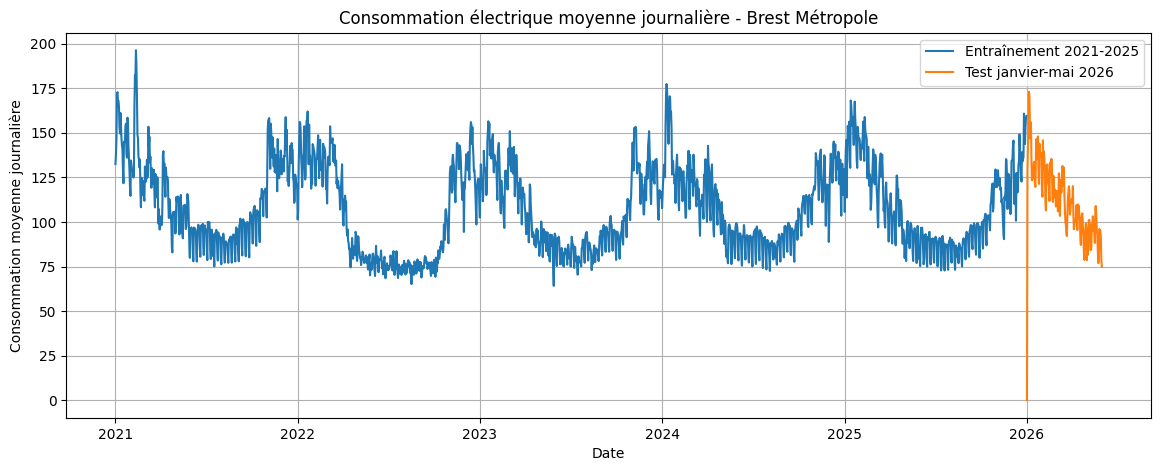

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_train_daily["date_jour"],
    df_train_daily["consommation_moyenne_journaliere"],
    label="Entraînement 2021-2025"
)

plt.plot(
    df_test_daily["date_jour"],
    df_test_daily["consommation_moyenne_journaliere"],
    label="Test janvier-mai 2026"
)

plt.title("Consommation électrique moyenne journalière - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

## C — Contrôle qualité des données

Sections 13 à 18

Contrôle qualité : valeurs nulles, journées incomplètes, anomalie source, exclusion propre du 1er janvier 2026.

## 13. Contrôle qualité des données journalières

Identification des journées incomplètes, des valeurs manquantes et des consommations nulles ou négatives.

Ce contrôle permet de repérer les valeurs susceptibles de perturber l'analyse exploratoire et les futurs modèles de prédiction.

In [14]:
# Ajout d'une colonne pour distinguer les périodes
df_train_controle = df_train_daily.copy()
df_train_controle["periode"] = "train"

df_test_controle = df_test_daily.copy()
df_test_controle["periode"] = "test"

# Regroupement des deux périodes
df_daily = pd.concat(
    [df_train_controle, df_test_controle],
    ignore_index=True
)

# Identification des lignes problématiques
df_daily["jour_incomplet"] = df_daily["nb_mesures_jour"] != 96
df_daily["consommation_manquante"] = df_daily["consommation_moyenne_journaliere"].isna()
df_daily["consommation_suspecte"] = df_daily["consommation_moyenne_journaliere"] <= 0

df_anomalies_qualite = df_daily[
    df_daily["jour_incomplet"] |
    df_daily["consommation_manquante"] |
    df_daily["consommation_suspecte"]
]

print("Nombre total de jours :", len(df_daily))
print("Nombre de jours à contrôler :", len(df_anomalies_qualite))

display(df_anomalies_qualite)

Nombre total de jours : 1977
Nombre de jours à contrôler : 191


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode,jour_incomplet,consommation_manquante,consommation_suspecte
0,2021-01-01,132.521739,92,train,True,False,False
28,2021-01-29,129.170213,94,train,True,False,False
29,2021-01-30,120.234043,94,train,True,False,False
30,2021-01-31,114.638298,94,train,True,False,False
31,2021-02-01,134.521277,94,train,True,False,False
...,...,...,...,...,...,...,...
726,2022-12-28,123.968421,95,train,True,False,False
727,2022-12-29,124.242105,95,train,True,False,False
790,2023-03-02,150.948276,58,train,True,False,False
807,2023-03-19,104.829787,94,train,True,False,False


## 14. Diagnostic qualité détaillé des données journalières

Analyse détaillée de la qualité des données journalières.

Cette étape ne modifie pas les données. Elle sert à identifier les journées incomplètes, les consommations nulles ou négatives, les valeurs extrêmes et le comportement autour du 1er janvier 2026.

In [15]:
# Reconstruction d'un jeu complet pour le diagnostic
df_train_diag = df_train_daily.copy()
df_train_diag["periode"] = "train"

df_test_diag = df_test_daily.copy()
df_test_diag["periode"] = "test"

df_daily_diag = pd.concat(
    [df_train_diag, df_test_diag],
    ignore_index=True
).sort_values("date_jour").reset_index(drop=True)


# 1. Distribution du nombre de mesures par jour
print("Distribution du nombre de mesures par jour :")
display(
    df_daily_diag["nb_mesures_jour"]
    .value_counts()
    .sort_index()
    .rename_axis("nb_mesures_jour")
    .reset_index(name="nombre_de_jours")
)


# 2. Jours avec moins de 96 mesures
df_jours_incomplets = df_daily_diag[
    df_daily_diag["nb_mesures_jour"] != 96
]

print("Nombre de jours avec un nombre de mesures différent de 96 :", len(df_jours_incomplets))
display(df_jours_incomplets.head(20))


# 3. Consommations nulles ou négatives
df_conso_nulles = df_daily_diag[
    df_daily_diag["consommation_moyenne_journaliere"] <= 0
]

print("Nombre de jours avec consommation nulle ou négative :", len(df_conso_nulles))
display(df_conso_nulles)


# 4. Valeurs les plus faibles
print("10 consommations moyennes journalières les plus faibles :")
display(
    df_daily_diag
    .sort_values("consommation_moyenne_journaliere")
    .head(10)
)


# 5. Valeurs les plus élevées
print("10 consommations moyennes journalières les plus élevées :")
display(
    df_daily_diag
    .sort_values("consommation_moyenne_journaliere", ascending=False)
    .head(10)
)


# 6. Zoom autour du 1er janvier 2026
df_zoom_2026 = df_daily_diag[
    (df_daily_diag["date_jour"] >= "2025-12-25") &
    (df_daily_diag["date_jour"] <= "2026-01-10")
]

print("Zoom autour du 1er janvier 2026 :")
display(df_zoom_2026)

Distribution du nombre de mesures par jour :


,nb_mesures_jour,nombre_de_jours
0,6,1
1,38,1
2,58,1
3,62,1
4,70,1
5,72,1
6,73,1
7,76,2
8,80,1
9,83,1


Nombre de jours avec un nombre de mesures différent de 96 : 191


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode
0,2021-01-01,132.521739,92,train
28,2021-01-29,129.170213,94,train
29,2021-01-30,120.234043,94,train
30,2021-01-31,114.638298,94,train
31,2021-02-01,134.521277,94,train
32,2021-02-02,131.978723,94,train
33,2021-02-03,129.361702,94,train
34,2021-02-04,128.563830,94,train
35,2021-02-05,128.542553,94,train
36,2021-02-06,124.914894,94,train


Nombre de jours avec consommation nulle ou négative : 1


...

,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode
1826,2026-01-01,0.000000,92,test
878,2023-05-29,64.145833,96,train
593,2022-08-17,65.156250,96,train
541,2022-06-26,68.479167,96,train
566,2022-07-21,68.562500,96,train
613,2022-09-06,68.854167,96,train
592,2022-08-16,69.156250,96,train
641,2022-10-04,69.239583,96,train
520,2022-06-05,69.656250,96,train
632,2022-09-25,69.718750,96,train


10 consommations moyennes journalières les plus élevées :


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode
41,2021-02-11,196.357895,95,train
42,2021-02-12,187.340426,94,train
39,2021-02-09,182.294737,95,train
40,2021-02-10,181.568421,95,train
1104,2024-01-10,177.395833,96,train
1105,2024-01-11,173.885417,96,train
1830,2026-01-05,173.052083,96,test
4,2021-01-05,172.843750,96,train
3,2021-01-04,171.770833,96,train
1103,2024-01-09,171.572917,96,train


Zoom autour du 1er janvier 2026 :


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode
1819,2025-12-25,136.156250,96,train
1820,2025-12-26,160.781250,96,train
1821,2025-12-27,153.083333,96,train
1822,2025-12-28,143.697917,96,train
1823,2025-12-29,153.114583,96,train
1824,2025-12-30,157.885417,96,train
1825,2025-12-31,159.489583,96,train
1826,2026-01-01,0.000000,92,test
1827,2026-01-02,129.083333,96,test
1828,2026-01-03,143.187500,96,test


## 15. Diagnostic ciblé du 1er janvier 2026

Analyse des données brutes du 1er janvier 2026 afin de comprendre l'origine de la consommation moyenne journalière égale à zéro.

In [16]:
df_test_raw_controle = df_test_raw.copy()

# Conversion uniquement des colonnes nécessaires au diagnostic
df_test_raw_controle["date"] = pd.to_datetime(df_test_raw_controle["date"])
df_test_raw_controle["consommation"] = pd.to_numeric(
    df_test_raw_controle["consommation"],
    errors="coerce"
)

# Filtrage des lignes brutes du 1er janvier 2026
df_2026_01_01 = df_test_raw_controle[
    df_test_raw_controle["date"] == "2026-01-01"
].copy()

print("Nombre de mesures le 2026-01-01 :", len(df_2026_01_01))
print("Consommation minimale :", df_2026_01_01["consommation"].min())
print("Consommation maximale :", df_2026_01_01["consommation"].max())
print("Consommation moyenne :", df_2026_01_01["consommation"].mean())
print("Nombre de valeurs nulles :", (df_2026_01_01["consommation"] == 0).sum())
print("Nombre de valeurs manquantes :", df_2026_01_01["consommation"].isna().sum())

display(df_2026_01_01[["date", "heures", "date_heure", "consommation"]].head(20))
display(df_2026_01_01[["date", "heures", "date_heure", "consommation"]].tail(20))

Nombre de mesures le 2026-01-01 : 92
Consommation minimale : 0.0
Consommation maximale : 0.0
Consommation moyenne : 0.0
Nombre de valeurs nulles : 92
Nombre de valeurs manquantes : 0


,date,heures,date_heure,consommation
0,2026-01-01,01:00,2026-01-01T01:00:00+01:00,0.0
1,2026-01-01,01:15,2026-01-01T01:15:00+01:00,0.0
2,2026-01-01,01:30,2026-01-01T01:30:00+01:00,0.0
3,2026-01-01,01:45,2026-01-01T01:45:00+01:00,0.0
4,2026-01-01,02:00,2026-01-01T02:00:00+01:00,0.0
5,2026-01-01,02:15,2026-01-01T02:15:00+01:00,0.0
6,2026-01-01,02:30,2026-01-01T02:30:00+01:00,0.0
7,2026-01-01,02:45,2026-01-01T02:45:00+01:00,0.0
8,2026-01-01,03:00,2026-01-01T03:00:00+01:00,0.0
9,2026-01-01,03:15,2026-01-01T03:15:00+01:00,0.0


,date,heures,date_heure,consommation
72,2026-01-01,19:00,2026-01-01T19:00:00+01:00,0.0
73,2026-01-01,19:15,2026-01-01T19:15:00+01:00,0.0
74,2026-01-01,19:30,2026-01-01T19:30:00+01:00,0.0
75,2026-01-01,19:45,2026-01-01T19:45:00+01:00,0.0
76,2026-01-01,20:00,2026-01-01T20:00:00+01:00,0.0
77,2026-01-01,20:15,2026-01-01T20:15:00+01:00,0.0
78,2026-01-01,20:30,2026-01-01T20:30:00+01:00,0.0
79,2026-01-01,20:45,2026-01-01T20:45:00+01:00,0.0
80,2026-01-01,21:00,2026-01-01T21:00:00+01:00,0.0
81,2026-01-01,21:15,2026-01-01T21:15:00+01:00,0.0


## 16. Comparaison des 1ers janvier

Comparaison des consommations moyennes journalières des 1ers janvier afin de vérifier si la valeur nulle du 1er janvier 2026 est cohérente avec les années précédentes.

In [17]:
df_premiers_janvier = df_daily_diag[
    (df_daily_diag["date_jour"].dt.month == 1) &
    (df_daily_diag["date_jour"].dt.day == 1)
].copy()

df_premiers_janvier

,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,periode
0,2021-01-01,132.521739,92,train
365,2022-01-01,101.427083,96,train
730,2023-01-01,102.489583,96,train
1095,2024-01-01,107.750000,96,train
1461,2025-01-01,105.614583,96,train
1826,2026-01-01,0.000000,92,test


## 17. Création du jeu de test pour l'évaluation

Création d'un jeu de test dédié à l'évaluation des modèles.

Le 1er janvier 2026 est exclu du jeu d'évaluation, car le diagnostic qualité a montré que toutes les mesures disponibles pour cette journée sont égales à zéro. Cette valeur est considérée comme une anomalie de qualité de donnée source.

In [18]:
# Création d'une copie du jeu de test journalier
df_test_eval = df_test_daily.copy()

# Identification de la journée exclue de l'évaluation
date_exclue = pd.to_datetime("2026-01-01")

df_jour_exclu_eval = df_test_eval[
    df_test_eval["date_jour"] == date_exclue
].copy()

# Exclusion de la journée problématique du jeu d'évaluation
df_test_eval = df_test_eval[
    df_test_eval["date_jour"] != date_exclue
].copy()

print("Jeu de test initial :", df_test_daily.shape)
print("Jeu de test pour évaluation :", df_test_eval.shape)

print("\nJournée exclue de l'évaluation :")
display(df_jour_exclu_eval)

print("\nContrôle des consommations nulles ou négatives dans le jeu d'évaluation :")
print((df_test_eval["consommation_moyenne_journaliere"] <= 0).sum())

Jeu de test initial : (151, 3)
Jeu de test pour évaluation : (150, 3)

Journée exclue de l'évaluation :


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour
0,2026-01-01,0.0,92



Contrôle des consommations nulles ou négatives dans le jeu d'évaluation :
0


## 18. Visualisation après exclusion de l'anomalie source

Visualisation de la consommation moyenne journalière après exclusion du 1er janvier 2026 du jeu de test d'évaluation.

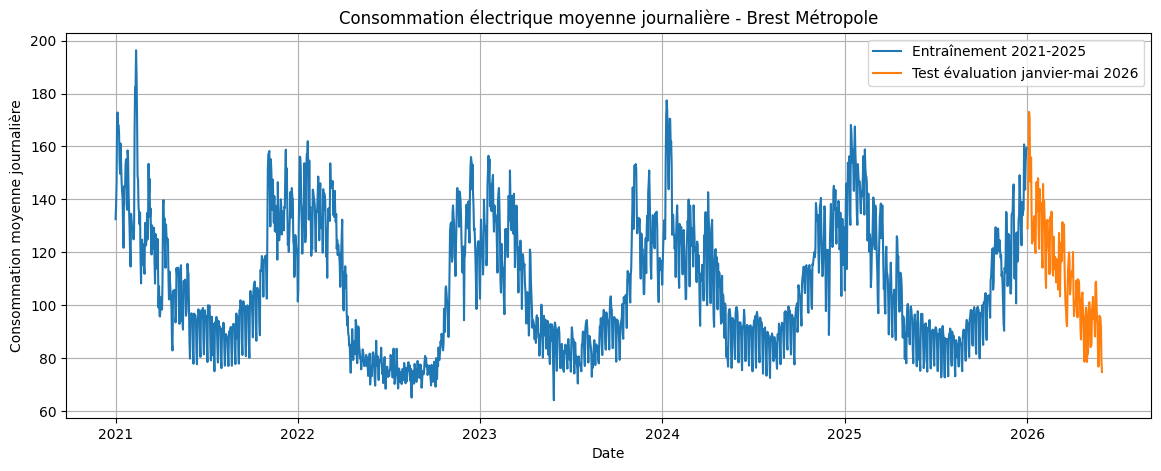

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_train_daily["date_jour"],
    df_train_daily["consommation_moyenne_journaliere"],
    label="Entraînement 2021-2025"
)

plt.plot(
    df_test_eval["date_jour"],
    df_test_eval["consommation_moyenne_journaliere"],
    label="Test évaluation janvier-mai 2026"
)

plt.title("Consommation électrique moyenne journalière - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

## D — Préparation pour la modélisation et baseline univariée

Sections 19 à 22

Préparation de la série pour les modèles + première baseline univariée : Seasonal Naive Forecast et son évaluation (MAE, RMSE, MAPE). Mise en place d'un point de comparaison minimal avant d'entamer la modélisation.

## 19. Vérification de la continuité temporelle

Contrôle de la présence de toutes les dates attendues dans les jeux d'entraînement et de test d'évaluation.

Cette vérification permet de s'assurer que les séries temporelles journalières sont régulières avant la modélisation.

In [20]:
def verifier_continuite_temporelle(df, date_colonne, nom_jeu):
    date_min = df[date_colonne].min()
    date_max = df[date_colonne].max()

    dates_attendues = pd.date_range(
        start=date_min,
        end=date_max,
        freq="D"
    )

    dates_presentes = pd.DatetimeIndex(df[date_colonne])

    dates_manquantes = dates_attendues.difference(dates_presentes)

    print(f"{nom_jeu}")
    print("Date de début :", date_min)
    print("Date de fin   :", date_max)
    print("Nombre de jours attendus :", len(dates_attendues))
    print("Nombre de jours présents :", len(dates_presentes))
    print("Nombre de dates manquantes :", len(dates_manquantes))

    if len(dates_manquantes) > 0:
        display(pd.DataFrame({"dates_manquantes": dates_manquantes}))


verifier_continuite_temporelle(
    df_train_daily,
    "date_jour",
    "Jeu d'entraînement"
)

print("\n")

verifier_continuite_temporelle(
    df_test_eval,
    "date_jour",
    "Jeu de test d'évaluation"
)

Jeu d'entraînement
Date de début : 2021-01-01 00:00:00
Date de fin   : 2025-12-31 00:00:00
Nombre de jours attendus : 1826
Nombre de jours présents : 1826
Nombre de dates manquantes : 0


Jeu de test d'évaluation
Date de début : 2026-01-02 00:00:00
Date de fin   : 2026-05-31 00:00:00
Nombre de jours attendus : 150
Nombre de jours présents : 150
Nombre de dates manquantes : 0


## 20. Mise au format série temporelle

Transformation des jeux de données journaliers en séries temporelles exploitables pour les modèles de prédiction.

La date devient l'index de la série et la fréquence journalière est explicitement définie.

In [21]:
# Création de la série temporelle d'entraînement
y_train = (
    df_train_daily
    .set_index("date_jour")["consommation_moyenne_journaliere"]
    .asfreq("D")
)

# Création de la série temporelle de test pour l'évaluation
y_test = (
    df_test_eval
    .set_index("date_jour")["consommation_moyenne_journaliere"]
    .asfreq("D")
)

print("Série d'entraînement")
print("Début :", y_train.index.min())
print("Fin   :", y_train.index.max())
print("Nombre de valeurs :", len(y_train))
print("Valeurs manquantes :", y_train.isna().sum())
print("Fréquence :", y_train.index.freq)

print("\nSérie de test")
print("Début :", y_test.index.min())
print("Fin   :", y_test.index.max())
print("Nombre de valeurs :", len(y_test))
print("Valeurs manquantes :", y_test.isna().sum())
print("Fréquence :", y_test.index.freq)

display(y_train.head())
display(y_test.head())

Série d'entraînement
Début : 2021-01-01 00:00:00
Fin   : 2025-12-31 00:00:00
Nombre de valeurs : 1826
Valeurs manquantes : 0
Fréquence : <Day>

Série de test
Début : 2026-01-02 00:00:00
Fin   : 2026-05-31 00:00:00
Nombre de valeurs : 150
Valeurs manquantes : 0
Fréquence : <Day>


date_jour
2021-01-01    132.521739
2021-01-02    137.958333
2021-01-03    146.510417
2021-01-04    171.770833
2021-01-05    172.843750
Freq: D, Name: consommation_moyenne_journaliere, dtype: float64

date_jour
2026-01-02    129.083333
2026-01-03    143.187500
2026-01-04    149.760417
2026-01-05    173.052083
2026-01-06    170.364583
Freq: D, Name: consommation_moyenne_journaliere, dtype: float64

## 21. Baseline — Seasonal Naive Forecast (J-7)

Création d'un modèle de référence simple basé sur la consommation observée 7 jours auparavant.

Le Seasonal Naive Forecast, ou baseline naïve saisonnière hebdomadaire, prédit chaque jour à partir de la consommation observée une semaine plus tôt. Dans ce projet, la saisonnalité utilisée est donc hebdomadaire.

Cette baseline sert de point de comparaison minimal avant l'utilisation de modèles plus complexes comme ARIMA, SARIMA ou TBATS. Les modèles plus avancés devront obtenir de meilleurs résultats que cette baseline pour être considérés comme utiles.

In [22]:
# Regroupement des séries train et test afin de disposer de l'historique nécessaire
y_all = pd.concat([y_train, y_test])

# Création d'une prédiction naïve saisonnière hebdomadaire
# Pour chaque jour du test, la prédiction correspond à la consommation observée 7 jours avant.
y_pred_baseline = y_all.shift(7).loc[y_test.index]

# Création d'un tableau de comparaison
df_baseline = pd.DataFrame({
    "consommation_reelle": y_test,
    "prediction_baseline_j_7": y_pred_baseline
})

display(df_baseline.head(10))

,consommation_reelle,prediction_baseline_j_7
date_jour,,
2026-01-02,129.083333,136.156250
2026-01-03,143.187500,160.781250
2026-01-04,149.760417,153.083333
2026-01-05,173.052083,143.697917
2026-01-06,170.364583,153.114583
2026-01-07,152.968750,157.885417
2026-01-08,146.739583,159.489583
2026-01-09,155.906250,129.083333
2026-01-10,135.447917,143.187500


## 22. Évaluation de la baseline — Seasonal Naive Forecast

Évaluation du modèle de référence Seasonal Naive Forecast avec trois métriques : MAE, RMSE et MAPE.

Cette baseline utilise la consommation observée 7 jours auparavant comme prédiction. Les scores obtenus servent de point de comparaison pour les futurs modèles ARIMA, SARIMA ou auto-ARIMA.

In [23]:
# Suppression éventuelle des lignes incomplètes
df_baseline_eval = df_baseline.dropna().copy()

# Récupération des valeurs réelles et prédites
y_true_baseline = df_baseline_eval["consommation_reelle"]
y_pred_baseline_eval = df_baseline_eval["prediction_baseline_j_7"]

# Calcul des métriques
mae_baseline = np.mean(np.abs(y_true_baseline - y_pred_baseline_eval))
rmse_baseline = np.sqrt(np.mean((y_true_baseline - y_pred_baseline_eval) ** 2))
mape_baseline = np.mean(np.abs((y_true_baseline - y_pred_baseline_eval) / y_true_baseline)) * 100

# Stockage des résultats pour le tableau comparatif final
resultats_baseline = {
    "modele": "Seasonal Naive Forecast (J-7)",
    "MAE": round(float(mae_baseline), 2),
    "RMSE": round(float(rmse_baseline), 2),
    "MAPE (%)": round(float(mape_baseline), 2)
}

print("Évaluation de la baseline — Seasonal Naive Forecast")
print("MAE  :", resultats_baseline["MAE"])
print("RMSE :", resultats_baseline["RMSE"])
print("MAPE :", resultats_baseline["MAPE (%)"], "%")

Évaluation de la baseline — Seasonal Naive Forecast
MAE  : 9.35
RMSE : 12.34
MAPE : 8.3 %


### 22.1 Visualisation des prédictions de la baseline — Seasonal Naive Forecast

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions de la baseline Seasonal Naive Forecast.

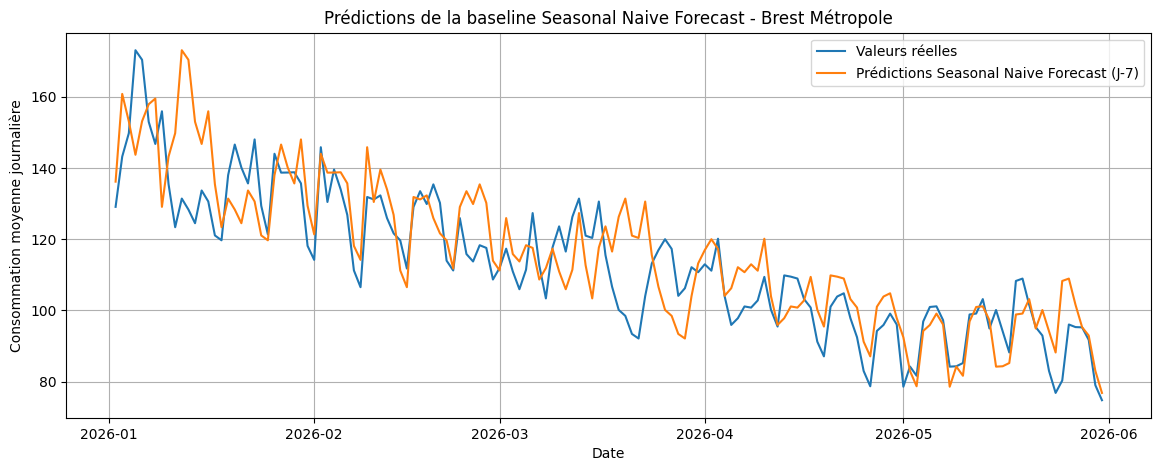

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_baseline_eval.index,
    df_baseline_eval["consommation_reelle"],
    label="Valeurs réelles"
)

plt.plot(
    df_baseline_eval.index,
    df_baseline_eval["prediction_baseline_j_7"],
    label="Prédictions Seasonal Naive Forecast (J-7)"
)

plt.title("Prédictions de la baseline Seasonal Naive Forecast - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 22.2 Interprétation de la baseline — Seasonal Naive Forecast

La baseline Seasonal Naive Forecast utilise la consommation observée 7 jours auparavant comme prédiction.

Cette approche constitue un modèle de référence pertinent pour cette série, car la consommation électrique peut présenter une saisonnalité hebdomadaire.

Les résultats obtenus servent de point de comparaison minimal pour les modèles plus complexes. Un modèle ARIMA, SARIMA ou TBATS devra obtenir de meilleures métriques que cette baseline pour être considéré comme réellement utile.

## E — EDA : analyse exploratoire de la série temporelle

Sections 23 à 25

Tendance, saisonnalité hebdomadaire, stationnarité.

## 23. Analyse de la tendance — 30-day Moving Average

Visualisation de la consommation moyenne journalière avec une moyenne mobile sur 30 jours.

Le 30-day Moving Average permet de lisser les variations quotidiennes et de mieux observer la tendance générale de la série.

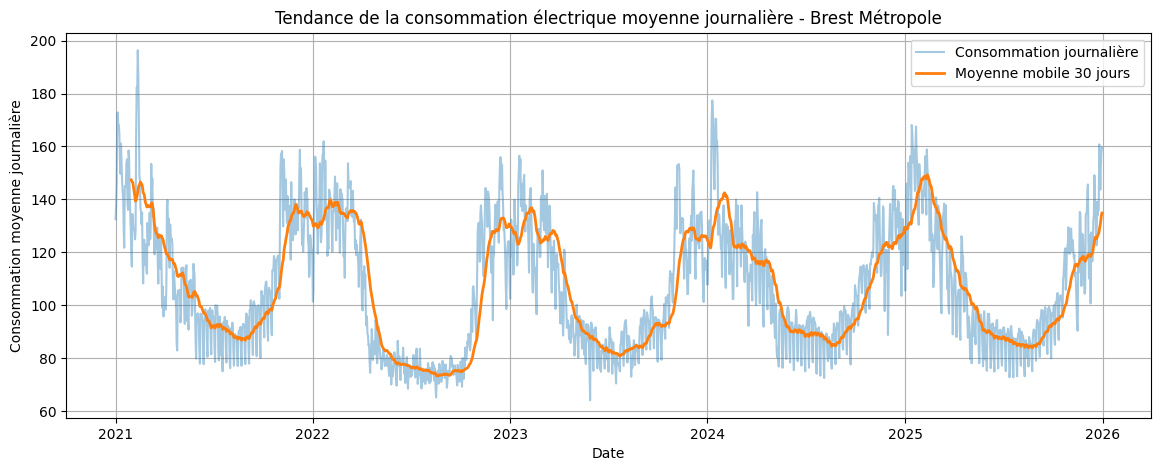

In [25]:
# Calcul d'une moyenne mobile sur 30 jours
y_train_moyenne_mobile_30j = y_train.rolling(window=30).mean()

plt.figure(figsize=(14, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Consommation journalière",
    alpha=0.4
)

plt.plot(
    y_train_moyenne_mobile_30j.index,
    y_train_moyenne_mobile_30j,
    label="Moyenne mobile 30 jours",
    linewidth=2
)

plt.title("Tendance de la consommation électrique moyenne journalière - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

## 24. Analyse de la saisonnalité hebdomadaire

Calcul de la consommation moyenne selon le jour de la semaine.

Cette analyse permet d'observer les différences de consommation entre les jours ouvrés et le week-end.

,jour_semaine_num,jour_semaine,consommation_moyenne_journaliere
0,0,Lundi,110.149468
1,1,Mardi,111.279217
2,2,Mercredi,110.920446
3,3,Jeudi,110.378078
4,4,Vendredi,109.783924
5,5,Samedi,101.897886
6,6,Dimanche,96.987502


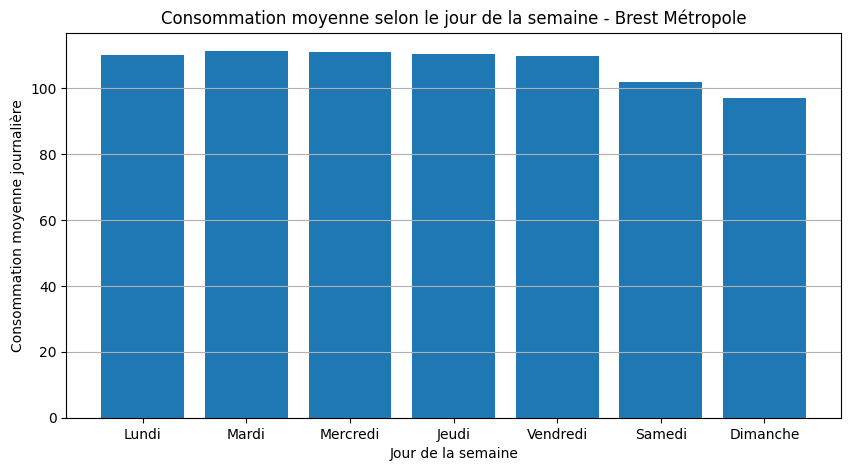

In [26]:
# Préparation d'un DataFrame à partir de la série d'entraînement
df_saisonnalite_hebdo = y_train.reset_index()
df_saisonnalite_hebdo.columns = ["date_jour", "consommation_moyenne_journaliere"]

# Extraction du jour de la semaine
df_saisonnalite_hebdo["jour_semaine_num"] = df_saisonnalite_hebdo["date_jour"].dt.dayofweek

jours_semaine = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche"
}

df_saisonnalite_hebdo["jour_semaine"] = df_saisonnalite_hebdo["jour_semaine_num"].map(jours_semaine)

# Calcul de la moyenne par jour de semaine
df_moyenne_par_jour = (
    df_saisonnalite_hebdo
    .groupby(["jour_semaine_num", "jour_semaine"], as_index=False)
    ["consommation_moyenne_journaliere"]
    .mean()
    .sort_values("jour_semaine_num")
)

display(df_moyenne_par_jour)

# Visualisation
plt.figure(figsize=(10, 5))

plt.bar(
    df_moyenne_par_jour["jour_semaine"],
    df_moyenne_par_jour["consommation_moyenne_journaliere"]
)

plt.title("Consommation moyenne selon le jour de la semaine - Brest Métropole")
plt.xlabel("Jour de la semaine")
plt.ylabel("Consommation moyenne journalière")
plt.grid(axis="y")
plt.show()

## 25. Test de stationnarité — Augmented Dickey-Fuller

Évaluation de la stationnarité de la série d'entraînement avec le test Augmented Dickey-Fuller.

Ce test permet de vérifier si la série présente une structure suffisamment stable dans le temps avant l'utilisation des modèles ARIMA ou SARIMA.

In [27]:
from statsmodels.tsa.stattools import adfuller

# Application du test ADF sur la série d'entraînement
resultat_adf = adfuller(y_train.dropna())

statistique_adf = resultat_adf[0]
p_value_adf = resultat_adf[1]

print("Test Augmented Dickey-Fuller")
print("Statistique ADF :", round(statistique_adf, 4))
print("p-value :", round(p_value_adf, 4))

if p_value_adf < 0.05:
    print("Interprétation : la série peut être considérée comme stationnaire au seuil de 5 %.")
else:
    print("Interprétation : la série ne peut pas être considérée comme stationnaire au seuil de 5 %.")

Test Augmented Dickey-Fuller
Statistique ADF : -2.6421
p-value : 0.0846
Interprétation : la série ne peut pas être considérée comme stationnaire au seuil de 5 %.


### 25.1 Test de stationnarité après différenciation

Application d'une première différenciation sur la série d'entraînement.

Cette étape permet de vérifier si la série devient stationnaire après transformation, ce qui aide à préparer le choix du paramètre `d` pour les modèles ARIMA.

In [28]:
# Première différenciation de la série d'entraînement
y_train_diff_1 = y_train.diff().dropna()

# Application du test ADF sur la série différenciée
resultat_adf_diff_1 = adfuller(y_train_diff_1)

statistique_adf_diff_1 = resultat_adf_diff_1[0]
p_value_adf_diff_1 = resultat_adf_diff_1[1]

print("Test Augmented Dickey-Fuller après première différenciation")
print("Statistique ADF :", round(statistique_adf_diff_1, 4))
print("p-value :", round(p_value_adf_diff_1, 4))

if p_value_adf_diff_1 < 0.05:
    print("Interprétation : la série différenciée peut être considérée comme stationnaire au seuil de 5 %.")
else:
    print("Interprétation : la série différenciée ne peut pas être considérée comme stationnaire au seuil de 5 %.")

Test Augmented Dickey-Fuller après première différenciation
Statistique ADF : -11.667
p-value : 0.0
Interprétation : la série différenciée peut être considérée comme stationnaire au seuil de 5 %.


La série d'entraînement brute ne peut pas être considérée comme stationnaire au seuil de 5 %, car la p-value du test ADF est supérieure à 0,05.

Après une première différenciation, la p-value devient inférieure à 0,05. La série différenciée peut donc être considérée comme stationnaire.

Cette étape indique qu'une différenciation d'ordre 1 peut être pertinente pour les futurs modèles ARIMA.

# Partie 2 — Modèles classiques de séries temporelles

Cette partie compare plusieurs modèles classiques de prévision sur la série univariée de consommation électrique : ARIMA, auto-ARIMA, SARIMA et TBATS.

Les performances sont comparées à la baseline Seasonal Naive Forecast.

## 26. Préparation des bibliothèques de modélisation

Import des bibliothèques nécessaires aux premiers modèles classiques de séries temporelles.

Une fonction d'évaluation commune est également définie afin de comparer les modèles avec les mêmes métriques : MAE, RMSE et MAPE.

In [29]:
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

def evaluer_modele(y_true, y_pred, nom_modele):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    resultats = {
        "modele": nom_modele,
        "MAE": round(float(mae), 2),
        "RMSE": round(float(rmse), 2),
        "MAPE (%)": round(float(mape), 2)
    }

    return resultats

## 27. Premier modèle ARIMA

Construction d'un premier modèle ARIMA manuel sur la série d'entraînement.

Le paramètre `d` est fixé à 1, car le test de stationnarité a montré qu'une première différenciation permet de rendre la série stationnaire.

Un premier modèle ARIMA(1, 1, 1) est testé comme point de départ avant l'utilisation d'auto-ARIMA.

In [30]:
# Création et entraînement d'un premier modèle ARIMA manuel
modele_arima_111 = ARIMA(
    y_train,
    order=(1, 1, 1)
)

resultat_arima_111 = modele_arima_111.fit()

print(resultat_arima_111.summary())

                                      SARIMAX Results                                       
Dep. Variable:     consommation_moyenne_journaliere   No. Observations:                 1826
Model:                               ARIMA(1, 1, 1)   Log Likelihood               -6462.796
Date:                              Wed, 03 Jun 2026   AIC                          12931.592
Time:                                      09:28:31   BIC                          12948.120
Sample:                                  01-01-2021   HQIC                         12937.689
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6427      0.026     24.265      0.000       0.591       0.695
ma.L1         -0.88

## 28. Évaluation du modèle ARIMA(1, 1, 1)

Prévision de la consommation moyenne journalière sur la période de test avec le modèle ARIMA(1, 1, 1).

Les prédictions sont comparées aux valeurs réelles du jeu de test d'évaluation avec les métriques MAE, RMSE et MAPE.

In [31]:
# Prévision avec le modèle ARIMA(1, 1, 1)
# Une journée supplémentaire est prédite afin de tenir compte du 1er janvier 2026 exclu du jeu d'évaluation.
prevision_arima_111 = resultat_arima_111.get_forecast(steps=len(y_test) + 1)

y_pred_arima_111_complet = prevision_arima_111.predicted_mean

# Conservation uniquement des dates présentes dans le jeu de test d'évaluation
y_pred_arima_111 = y_pred_arima_111_complet.loc[y_test.index]

# Évaluation du modèle
resultats_arima_111 = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_arima_111,
    nom_modele="ARIMA(1, 1, 1)"
)

resultats_arima_111

{'modele': 'ARIMA(1, 1, 1)', 'MAE': 34.74, 'RMSE': 39.01, 'MAPE (%)': 34.33}

### 28.1 Visualisation des prédictions ARIMA(1, 1, 1)

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions du modèle ARIMA(1, 1, 1).

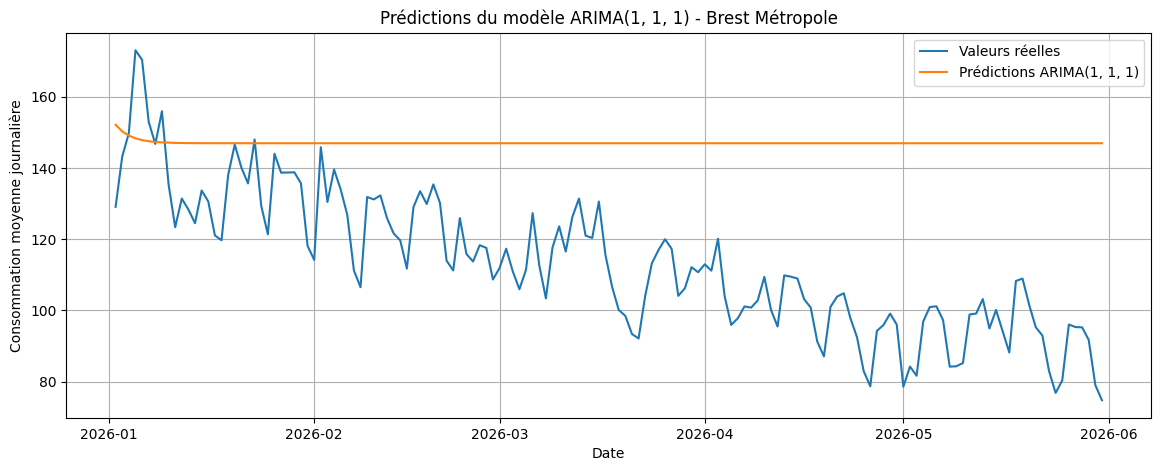

In [32]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Valeurs réelles"
)

plt.plot(
    y_pred_arima_111.index,
    y_pred_arima_111,
    label="Prédictions ARIMA(1, 1, 1)"
)

plt.title("Prédictions du modèle ARIMA(1, 1, 1) - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 28.2 Interprétation du modèle ARIMA(1, 1, 1)

ARIMA(1, 1, 1) ne constitue pas un bon modèle pour cette série. Il ne capture pas correctement la baisse saisonnière observée sur la période de test. Un modèle intégrant mieux la saisonnalité, comme SARIMA ou un auto-ARIMA saisonnier, devra être testé.

## 29. Modèle auto-ARIMA non saisonnier

Recherche automatique des paramètres du modèle ARIMA avec `pmdarima`.

Le paramètre `d` est fixé à 1, car le test Augmented Dickey-Fuller a montré qu'une première différenciation permet de rendre la série stationnaire.

Cette étape permet de comparer un ARIMA choisi automatiquement avec le premier modèle ARIMA(1, 1, 1).

In [33]:
# Recherche automatique des paramètres ARIMA non saisonniers
modele_auto_arima = pm.auto_arima(
    y_train,
    d=1,
    seasonal=False,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print(modele_auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13106.734, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=13106.821, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=13104.272, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=13104.739, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=12933.592, Time=1.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=12866.883, Time=1.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=12956.138, Time=0.21 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=12859.531, Time=1.64 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=12953.202, Time=1.67 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=12817.187, Time=1.82 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=12911.944, Time=2.38 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=12697.974, Time=3.46 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=12712.789, Time=3.21 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=12455.415, Time=10.77 sec
 ARIMA(4,1,2)(0,0,

## 30. Évaluation du modèle auto-ARIMA non saisonnier

Prévision de la consommation moyenne journalière sur la période de test avec le modèle auto-ARIMA sélectionné par `pmdarima`.

Les prédictions sont comparées aux valeurs réelles du jeu de test d'évaluation avec les métriques MAE, RMSE et MAPE.

In [34]:
# Prévision avec le modèle auto-ARIMA
# Une journée supplémentaire est prédite afin de tenir compte du 1er janvier 2026 exclu du jeu d'évaluation.
n_periodes = len(y_test) + 1

predictions_auto_arima = modele_auto_arima.predict(n_periods=n_periodes)

# Création de l'index temporel complet des prédictions
index_predictions_auto_arima = pd.date_range(
    start=y_train.index.max() + pd.Timedelta(days=1),
    periods=n_periodes,
    freq="D"
)

y_pred_auto_arima_complet = pd.Series(
    predictions_auto_arima,
    index=index_predictions_auto_arima
)

# Conservation uniquement des dates présentes dans le jeu de test d'évaluation
y_pred_auto_arima = y_pred_auto_arima_complet.loc[y_test.index]

# Évaluation du modèle
resultats_auto_arima = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_auto_arima,
    nom_modele="auto-ARIMA(5, 1, 3)"
)

resultats_auto_arima

{'modele': 'auto-ARIMA(5, 1, 3)',
 'MAE': 44.96,
 'RMSE': 48.72,
 'MAPE (%)': 43.79}

### 30.1 Visualisation des prédictions auto-ARIMA non saisonnier

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions du modèle auto-ARIMA non saisonnier.

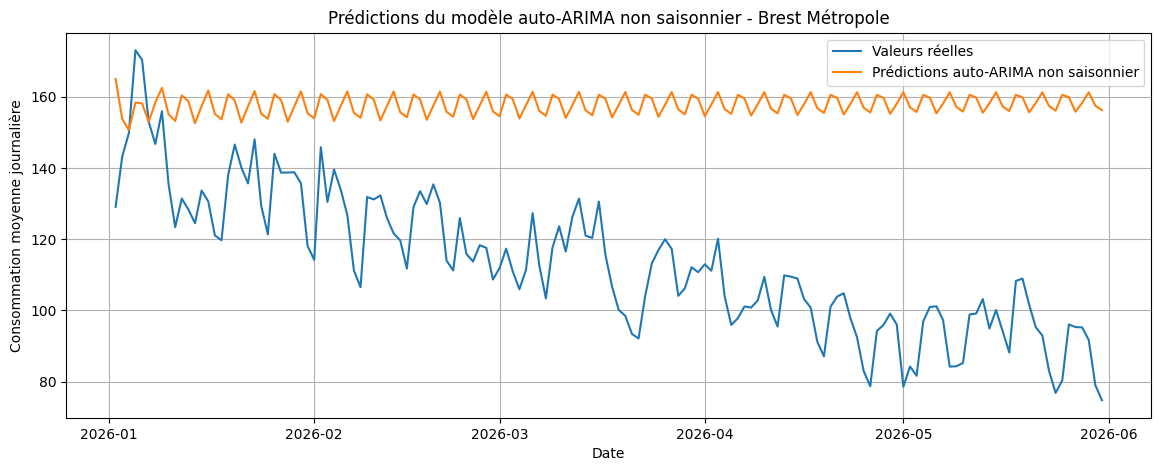

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Valeurs réelles"
)

plt.plot(
    y_pred_auto_arima.index,
    y_pred_auto_arima,
    label="Prédictions auto-ARIMA non saisonnier"
)

plt.title("Prédictions du modèle auto-ARIMA non saisonnier - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 30.2 Interprétation du modèle auto-ARIMA non saisonnier

Le modèle auto-ARIMA non saisonnier ne constitue pas un bon modèle pour cette série.

Les prédictions restent globalement trop élevées sur la période de test et ne suivent pas la baisse progressive de la consommation observée entre janvier et mai 2026.

Les métriques confirment cette limite, avec des erreurs supérieures à celles de la baseline Seasonal Naive Forecast. Un modèle prenant explicitement en compte la saisonnalité devra donc être testé.

## 31. Modèle SARIMA — auto-ARIMA saisonnier

Recherche automatique d'un modèle SARIMA avec `pmdarima`.

La série étant journalière, une saisonnalité hebdomadaire est testée avec `m = 7`.

Le paramètre `d` est fixé à 1, conformément au test de stationnarité réalisé précédemment.

In [36]:
# Recherche automatique d'un modèle SARIMA avec saisonnalité hebdomadaire
modele_sarima = pm.auto_arima(
    y_train,
    d=1,
    seasonal=True,
    m=7,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print(modele_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=13106.734, Time=0.32 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=12468.024, Time=6.50 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=12741.860, Time=5.17 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=13104.739, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=13106.821, Time=0.78 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=12235.215, Time=8.58 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=11864.893, Time=19.00 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=11863.464, Time=13.96 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=12742.302, Time=7.13 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=11864.922, Time=14.13 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=12542.793, Time=2.77 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=13.09 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=11864.531, Time=2.57 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=11837.851, Time=4.73 sec
 ARIMA(2,1,0)(0,0,1)[

### 31.1 Identification du modèle SARIMA retenu

Affichage des paramètres retenus automatiquement par `pmdarima` pour le modèle SARIMA saisonnier.

In [37]:
ordre_sarima = modele_sarima.order
ordre_saisonnier_sarima = modele_sarima.seasonal_order
aic_sarima = modele_sarima.aic()

nom_modele_sarima = f"SARIMA{ordre_sarima}{ordre_saisonnier_sarima}"

print("Ordre non saisonnier :", ordre_sarima)
print("Ordre saisonnier :", ordre_saisonnier_sarima)
print("AIC :", round(aic_sarima, 2))
print("Nom du modèle :", nom_modele_sarima)

Ordre non saisonnier : (2, 1, 2)
Ordre saisonnier : (1, 0, 1, 7)
AIC : 11785.72
Nom du modèle : SARIMA(2, 1, 2)(1, 0, 1, 7)


## 32. Évaluation du modèle SARIMA

Prévision de la consommation moyenne journalière sur la période de test avec le modèle SARIMA retenu automatiquement.

Les prédictions sont comparées aux valeurs réelles du jeu de test d'évaluation avec les métriques MAE, RMSE et MAPE.

In [38]:
# Prévision avec le modèle SARIMA
# Une journée supplémentaire est prédite afin de tenir compte du 1er janvier 2026 exclu du jeu d'évaluation.
n_periodes = len(y_test) + 1

predictions_sarima = modele_sarima.predict(n_periods=n_periodes)

# Création de l'index temporel complet des prédictions
index_predictions_sarima = pd.date_range(
    start=y_train.index.max() + pd.Timedelta(days=1),
    periods=n_periodes,
    freq="D"
)

y_pred_sarima_complet = pd.Series(
    predictions_sarima,
    index=index_predictions_sarima
)

# Conservation uniquement des dates présentes dans le jeu de test d'évaluation
y_pred_sarima = y_pred_sarima_complet.loc[y_test.index]

# Évaluation du modèle
resultats_sarima = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_sarima,
    nom_modele="SARIMA(2, 1, 2)(1, 0, 1, 7)"
)

resultats_sarima

{'modele': 'SARIMA(2, 1, 2)(1, 0, 1, 7)',
 'MAE': 66.24,
 'RMSE': 74.32,
 'MAPE (%)': 65.16}

### 32.1 Visualisation des prédictions SARIMA

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions du modèle SARIMA.

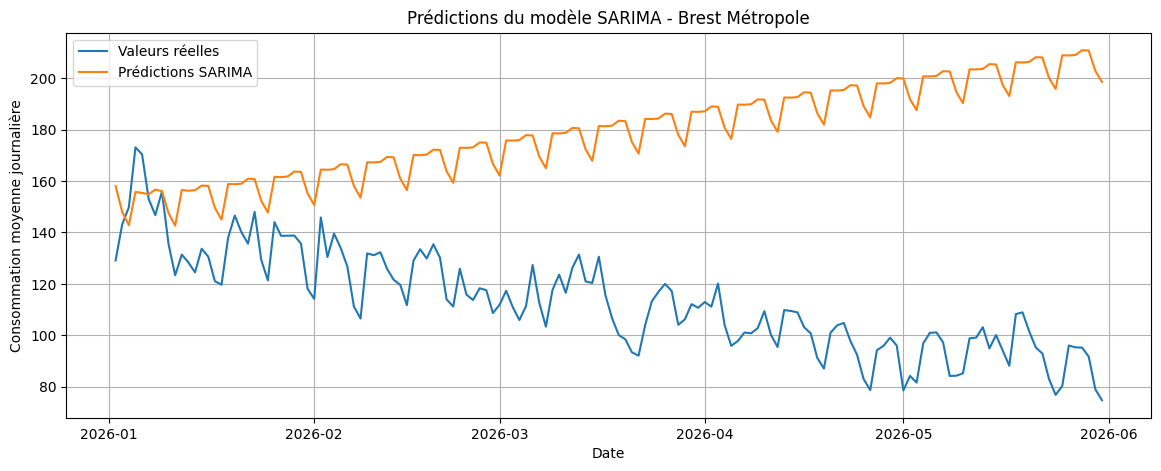

In [39]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Valeurs réelles"
)

plt.plot(
    y_pred_sarima.index,
    y_pred_sarima,
    label="Prédictions SARIMA"
)

plt.title("Prédictions du modèle SARIMA - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 32.2 Interprétation du modèle SARIMA

Le modèle SARIMA(2, 1, 2)(1, 0, 1, 7) ne constitue pas un bon modèle pour cette série.

La visualisation montre que les prédictions augmentent progressivement sur la période de test, alors que les valeurs réelles diminuent globalement entre janvier et mai 2026.

Le modèle semble capter une oscillation hebdomadaire, visible dans les variations régulières des prédictions, mais il ne reproduit pas correctement le niveau de consommation ni la tendance observée.

Les métriques confirment cette limite, avec des erreurs nettement supérieures à celles de la baseline Seasonal Naive Forecast. Pour cette série, le SARIMA testé n'apporte donc pas d'amélioration par rapport au modèle de référence.

## 33. Modèle TBATS

Construction d'un modèle TBATS sur la série d'entraînement.

Le modèle est configuré avec une saisonnalité hebdomadaire (`seasonal_periods=[7]`) afin de tenir compte des variations récurrentes observées selon les jours de la semaine.

Pour limiter le temps de calcul dans le cadre du PoC, certaines options automatiques du modèle sont désactivées.

In [40]:
from tbats import TBATS

# Initialisation d'un modèle TBATS contraint pour limiter le temps de calcul
estimateur_tbats = TBATS(
    seasonal_periods=[7],
    use_box_cox=False,
    use_trend=True,
    use_damped_trend=False,
    use_arma_errors=False,
    show_warnings=False,
    n_jobs=1
)

# Entraînement du modèle sur la série d'entraînement
modele_tbats = estimateur_tbats.fit(y_train.values)

print(modele_tbats.summary())

/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: '

Use Box-Cox: False
Use trend: True
Use damped trend: False
Seasonal periods: [7.]
Seasonal harmonics [3]
ARMA errors (p, q): (0, 0)
Smoothing (Alpha): 0.939769
Trend (Beta): 0.008897
Damping Parameter (Phi): 1.000000
Seasonal Parameters (Gamma): [-2.19900132e-08 -1.99095559e-07]
AR coefficients []
MA coefficients []
Seed vector [158.61935425   2.91082968  -0.9960166    3.78557833  -0.37108776
  -5.95747912  -0.44035264   1.72030625]

AIC 20490.573158


/home/carole/iadev/time_series/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 34. Évaluation du modèle TBATS

Prévision de la consommation moyenne journalière sur la période de test avec le modèle TBATS.

Les prédictions sont comparées aux valeurs réelles du jeu de test d'évaluation avec les métriques MAE, RMSE et MAPE.

In [41]:
# Prévision avec le modèle TBATS
# Une journée supplémentaire est prédite afin de tenir compte du 1er janvier 2026 exclu du jeu d'évaluation.
n_periodes = len(y_test) + 1

predictions_tbats = modele_tbats.forecast(steps=n_periodes)

# Création de l'index temporel complet des prédictions
index_predictions_tbats = pd.date_range(
    start=y_train.index.max() + pd.Timedelta(days=1),
    periods=n_periodes,
    freq="D"
)

y_pred_tbats_complet = pd.Series(
    predictions_tbats,
    index=index_predictions_tbats
)

# Conservation uniquement des dates présentes dans le jeu de test d'évaluation
y_pred_tbats = y_pred_tbats_complet.loc[y_test.index]

# Évaluation du modèle
resultats_tbats = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_tbats,
    nom_modele="TBATS"
)

resultats_tbats

{'modele': 'TBATS', 'MAE': 75.74, 'RMSE': 83.68, 'MAPE (%)': 74.07}

### 34.1 Visualisation des prédictions TBATS

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions du modèle TBATS.

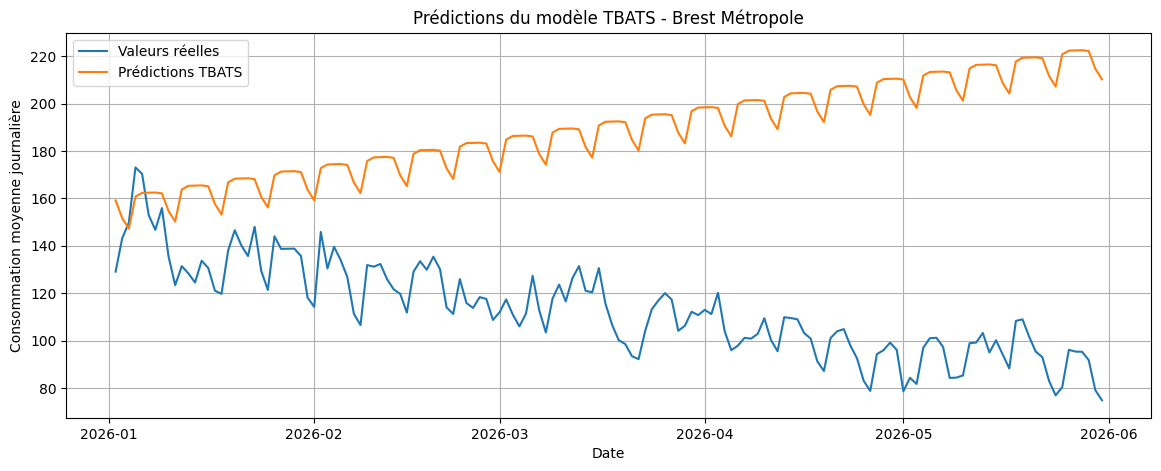

In [42]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Valeurs réelles"
)

plt.plot(
    y_pred_tbats.index,
    y_pred_tbats,
    label="Prédictions TBATS"
)

plt.title("Prédictions du modèle TBATS - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 34.2 Interprétation du modèle TBATS

Le modèle TBATS testé ne constitue pas un bon modèle pour cette série dans cette configuration.

La visualisation montre que les prédictions augmentent progressivement sur la période de test, alors que les valeurs réelles diminuent globalement entre janvier et mai 2026.

Le modèle semble capter une oscillation régulière, mais il ne reproduit pas correctement la tendance observée ni le niveau réel de consommation.

Les métriques confirment cette limite, avec des erreurs nettement supérieures à celles de la baseline Seasonal Naive Forecast. Dans cette configuration, TBATS n'apporte donc pas d'amélioration par rapport au modèle de référence.

## 35. Comparaison des modèles classiques

Comparaison des performances des modèles classiques testés sur la série univariée de consommation électrique.

Les modèles sont comparés avec les mêmes métriques : MAE, RMSE et MAPE.

In [43]:
# Regroupement des résultats des modèles testés
resultats_modeles_classiques = [
    resultats_baseline,
    resultats_arima_111,
    resultats_auto_arima,
    resultats_sarima,
    resultats_tbats
]

df_comparaison_modeles = pd.DataFrame(resultats_modeles_classiques)

# Nettoyage des types numériques pour un affichage plus lisible
colonnes_scores = ["MAE", "RMSE", "MAPE (%)"]

for colonne in colonnes_scores:
    df_comparaison_modeles[colonne] = df_comparaison_modeles[colonne].astype(float)

# Tri des modèles du meilleur au moins bon selon la MAPE
df_comparaison_modeles = df_comparaison_modeles.sort_values("MAPE (%)").reset_index(drop=True)

df_comparaison_modeles

,modele,MAE,RMSE,MAPE (%)
0,Seasonal Naive Forecast (J-7),9.35,12.34,8.30
1,"ARIMA(1, 1, 1)",34.74,39.01,34.33
2,"auto-ARIMA(5, 1, 3)",44.96,48.72,43.79
3,"SARIMA(2, 1, 2)(1, 0, 1, 7)",66.24,74.32,65.16
4,TBATS,75.74,83.68,74.07


### 35.1 Interprétation de la comparaison des modèles classiques

Le tableau comparatif montre que la baseline Seasonal Naive Forecast (J-7) obtient les meilleurs résultats sur le jeu de test.

Les modèles ARIMA(1, 1, 1), auto-ARIMA non saisonnier, SARIMA hebdomadaire et TBATS présentent tous des erreurs nettement supérieures à celles de la baseline.

Cette comparaison indique que, dans cette première approche univariée, la consommation observée une semaine auparavant constitue une référence plus performante que les modèles classiques testés.

Les modèles plus complexes ne sont donc pas automatiquement meilleurs. Pour être retenus, ils doivent améliorer les métriques par rapport à la baseline. À ce stade, ce n'est pas le cas.

La série peut contenir plusieurs effets saisonniers, notamment hebdomadaires et annuels. Cette complexité peut limiter les performances des modèles univariés classiques, en particulier lorsqu'ils ne disposent pas encore de variables externes comme la météo ou les informations calendaires.

La suite du projet devra permettre d'évaluer si l'ajout de variables externes, comme la météo et le calendrier, améliore les performances de prédiction.

### 35.2 Sauvegarde des modèles classiques

Sauvegarde des modèles classiques entraînés au format `.pkl`.

Les modèles sont enregistrés afin de pouvoir être rechargés ultérieurement sans relancer leur entraînement.

In [44]:
import pickle
from pathlib import Path

# Création du dossier de sauvegarde des modèles
dossier_modeles = Path("../models")
dossier_modeles.mkdir(parents=True, exist_ok=True)

# Sauvegarde des modèles entraînés
modeles_a_sauvegarder = {
    "arima_111.pkl": resultat_arima_111,
    "auto_arima_513.pkl": modele_auto_arima,
    "sarima_212_101_7.pkl": modele_sarima,
    "tbats.pkl": modele_tbats
}

for nom_fichier, modele in modeles_a_sauvegarder.items():
    chemin_modele = dossier_modeles / nom_fichier

    with open(chemin_modele, "wb") as fichier:
        pickle.dump(modele, fichier)

    print("Modèle sauvegardé :", chemin_modele)

# Sauvegarde du tableau comparatif des scores
chemin_scores = dossier_modeles / "comparaison_modeles_classiques.csv"
df_comparaison_modeles.to_csv(chemin_scores, index=False)

print("Tableau comparatif sauvegardé :", chemin_scores)

Modèle sauvegardé : ../models/arima_111.pkl
Modèle sauvegardé : ../models/auto_arima_513.pkl
Modèle sauvegardé : ../models/sarima_212_101_7.pkl
Modèle sauvegardé : ../models/tbats.pkl
Tableau comparatif sauvegardé : ../models/comparaison_modeles_classiques.csv


### 35.3 Tableau de synthèse des performances

Création d'un tableau de synthèse des performances des modèles classiques.

Ce tableau est destiné à faciliter la comparaison des modèles et peut être utilisé pour la présentation du projet.

In [45]:
df_synthese_presentation = df_comparaison_modeles.copy()

# Renommage pour un affichage plus lisible
df_synthese_presentation = df_synthese_presentation.rename(columns={
    "modele": "Modèle"
})

# Ajout du rang
df_synthese_presentation.insert(
    0,
    "Rang",
    range(1, len(df_synthese_presentation) + 1)
)

# Arrondi des métriques
df_synthese_presentation["MAE"] = df_synthese_presentation["MAE"].round(2)
df_synthese_presentation["RMSE"] = df_synthese_presentation["RMSE"].round(2)
df_synthese_presentation["MAPE (%)"] = df_synthese_presentation["MAPE (%)"].round(2)

# Ajout d'une lecture rapide
df_synthese_presentation["Lecture"] = [
    "Meilleur modèle testé",
    "Moins performant que la baseline",
    "Moins performant que la baseline",
    "Moins performant que la baseline",
    "Moins performant que la baseline"
]

# Affichage stylisé dans le notebook
display(
    df_synthese_presentation.style
    .hide(axis="index")
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE (%)": "{:.2f}"
    })
    .background_gradient(
        subset=["MAE", "RMSE", "MAPE (%)"],
        cmap="RdYlGn_r"
    )
)

# Export pour partage éventuel avec l'équipe
chemin_synthese = Path("../models/synthese_performances_modeles_classiques.csv")
df_synthese_presentation.to_csv(chemin_synthese, index=False)

print("Tableau de synthèse sauvegardé :", chemin_synthese)

Rang,Modèle,MAE,RMSE,MAPE (%),Lecture
1,Seasonal Naive Forecast (J-7),9.35,12.34,8.30,Meilleur modèle testé
2,"ARIMA(1, 1, 1)",34.74,39.01,34.33,Moins performant que la baseline
3,"auto-ARIMA(5, 1, 3)",44.96,48.72,43.79,Moins performant que la baseline
4,"SARIMA(2, 1, 2)(1, 0, 1, 7)",66.24,74.32,65.16,Moins performant que la baseline
5,TBATS,75.74,83.68,74.07,Moins performant que la baseline


Tableau de synthèse sauvegardé : ../models/synthese_performances_modeles_classiques.csv


# Partie 3 — Enrichissement multivarié : météo et calendrier

Cette partie ajoute des variables explicatives externes à la consommation électrique : données météo issues d'Open-Meteo et informations calendaires.

L'objectif est de comparer une approche univariée, basée uniquement sur l'historique de consommation, avec une approche multivariée intégrant des facteurs externes.

## 36. Identification des coordonnées de Brest pour Open-Meteo

Recherche des coordonnées géographiques de Brest avec l'API de géocodage Open-Meteo.

Ces coordonnées seront utilisées pour récupérer les données météo historiques correspondant à la zone d'étude.

In [46]:
# Recherche des coordonnées de Brest avec l'API de géocodage Open-Meteo
url_geocoding = "https://geocoding-api.open-meteo.com/v1/search"

params_geocoding = {
    "name": "Brest",
    "count": 10,
    "language": "fr",
    "format": "json"
}

response_geocoding = requests.get(url_geocoding, params=params_geocoding)

print("Statut :", response_geocoding.status_code)

data_geocoding = response_geocoding.json()

df_geocoding = pd.DataFrame(data_geocoding["results"])

df_geocoding[[
    "name",
    "country",
    "admin1",
    "latitude",
    "longitude",
    "timezone"
]]

Statut : 200


,name,country,admin1,latitude,longitude,timezone
0,Brest,Biélorussie,Brest,52.10894,23.71749,Europe/Minsk
1,Brest,France,Bretagne,48.39029,-4.48628,Europe/Paris
2,Brest,Allemagne,Basse-Saxe,53.45018,9.38401,Europe/Berlin
3,Brest,Bulgarie,Pleven,43.64270,24.59162,Europe/Sofia
4,Brest,Bulgarie,Kyustendil,42.46233,22.60447,Europe/Sofia
5,Břest,Tchéquie,Zlín,49.35107,17.44072,Europe/Prague
6,Brest,Macédoine du Nord,Makedonski Brod,41.72469,21.15722,Europe/Skopje
7,Brest,Slovénie,Ig,45.97028,14.49667,Europe/Ljubljana
8,Brest,Croatie,Istrie,45.33250,14.15500,Europe/Zagreb
9,Brest,Croatie,Istrie,45.45389,14.00639,Europe/Zagreb


## 37. Sélection de Brest en France

Sélection de la ville de Brest située en France, en région Bretagne, parmi les résultats renvoyés par l'API de géocodage Open-Meteo.

Les coordonnées géographiques récupérées seront utilisées pour interroger l'API météo historique.

In [47]:
# Sélection de Brest en France, région Bretagne
df_brest_meteo = df_geocoding[
    (df_geocoding["name"] == "Brest") &
    (df_geocoding["country"] == "France") &
    (df_geocoding["admin1"] == "Bretagne")
].copy()

display(df_brest_meteo[[
    "name",
    "country",
    "admin1",
    "latitude",
    "longitude",
    "timezone"
]])

# Stockage des coordonnées pour les prochaines requêtes météo
latitude_brest = df_brest_meteo.iloc[0]["latitude"]
longitude_brest = df_brest_meteo.iloc[0]["longitude"]
timezone_brest = df_brest_meteo.iloc[0]["timezone"]

print("Latitude :", latitude_brest)
print("Longitude :", longitude_brest)
print("Timezone :", timezone_brest)

,name,country,admin1,latitude,longitude,timezone
1,Brest,France,Bretagne,48.39029,-4.48628,Europe/Paris


Latitude : 48.39029
Longitude : -4.48628
Timezone : Europe/Paris


## 38. Test de récupération des données météo historiques

Vérification de la récupération des données météo historiques avec l'API Open-Meteo.

Un premier test est réalisé sur quelques jours afin de contrôler la structure des données avant le téléchargement complet.

Les variables de température Open-Meteo correspondent à la température de l'air estimée à 2 mètres du sol. La variable de vent correspond à la vitesse du vent estimée à 10 mètres du sol.

In [48]:
# Test de récupération des données météo historiques avec Open-Meteo
url_meteo_archive = "https://archive-api.open-meteo.com/v1/archive"

params_meteo_test = {
    "latitude": latitude_brest,
    "longitude": longitude_brest,
    "start_date": "2021-01-01",
    "end_date": "2021-01-10",
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_min",
        "temperature_2m_max",
        "precipitation_sum",
        "wind_speed_10m_mean"
    ],
    "timezone": timezone_brest
}

response_meteo_test = requests.get(url_meteo_archive, params=params_meteo_test)

print("Statut :", response_meteo_test.status_code)

data_meteo_test = response_meteo_test.json()

df_meteo_test = pd.DataFrame(data_meteo_test["daily"])

df_meteo_test

Statut : 200


,time,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
0,2021-01-01,2.4,0.5,4.9,2.4,8.4
1,2021-01-02,4.6,1.5,7.2,2.4,11.9
2,2021-01-03,3.4,1.9,4.8,3.9,14.6
3,2021-01-04,3.4,1.2,6.0,1.7,12.2
4,2021-01-05,3.8,3.0,5.1,2.5,14.2
5,2021-01-06,2.5,0.4,5.4,0.3,5.4
6,2021-01-07,2.3,0.3,5.2,0.0,5.2
7,2021-01-08,2.7,0.2,4.8,1.1,5.8
8,2021-01-09,1.9,-0.7,5.2,0.0,10.3
9,2021-01-10,3.0,0.6,6.8,0.0,9.4


## 39. Récupération des données météo historiques

Récupération des données météo historiques pour Brest sur les périodes d'entraînement et de test.

Les données météo sont récupérées à l'échelle journalière afin d'être compatibles avec la série de consommation moyenne journalière.

In [49]:
def recuperer_meteo_historique(date_debut, date_fin, chemin_fichier):
    params_meteo = {
        "latitude": latitude_brest,
        "longitude": longitude_brest,
        "start_date": date_debut,
        "end_date": date_fin,
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_min",
            "temperature_2m_max",
            "precipitation_sum",
            "wind_speed_10m_mean"
        ],
        "timezone": timezone_brest
    }

    response = requests.get(url_meteo_archive, params=params_meteo)

    print("Statut :", response.status_code)

    response.raise_for_status()

    data_meteo = response.json()

    df_meteo = pd.DataFrame(data_meteo["daily"])

    df_meteo = df_meteo.rename(columns={
        "time": "date_jour"
    })

    df_meteo["date_jour"] = pd.to_datetime(df_meteo["date_jour"])

    df_meteo.to_csv(chemin_fichier, index=False)

    print("Fichier enregistré :", chemin_fichier)
    print("Dimensions :", df_meteo.shape)

    return df_meteo


dossier_raw = Path("../data/raw")
dossier_raw.mkdir(parents=True, exist_ok=True)

df_meteo_train = recuperer_meteo_historique(
    "2021-01-01",
    "2025-12-31",
    dossier_raw / "meteo_brest_train_2021_2025.csv"
)

df_meteo_test = recuperer_meteo_historique(
    "2026-01-01",
    "2026-05-31",
    dossier_raw / "meteo_brest_test_2026_01_01_2026_05_31.csv"
)

display(df_meteo_train.head())
display(df_meteo_test.head())

Statut : 200
Fichier enregistré : ../data/raw/meteo_brest_train_2021_2025.csv
Dimensions : (1826, 6)
Statut : 200
Fichier enregistré : ../data/raw/meteo_brest_test_2026_01_01_2026_05_31.csv
Dimensions : (151, 6)


,date_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
0,2021-01-01,2.4,0.5,4.9,2.4,8.4
1,2021-01-02,4.6,1.5,7.2,2.4,11.9
2,2021-01-03,3.4,1.9,4.8,3.9,14.6
3,2021-01-04,3.4,1.2,6.0,1.7,12.2
4,2021-01-05,3.8,3.0,5.1,2.5,14.2


,date_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
0,2026-01-01,2.6,-0.9,5.8,0.0,6.2
1,2026-01-02,5.8,4.2,8.9,0.0,9.6
2,2026-01-03,4.6,2.5,6.8,0.0,8.8
3,2026-01-04,2.6,0.9,5.4,0.2,4.9
4,2026-01-05,3.6,1.2,5.6,8.6,13.5


## 40. Contrôle qualité des données météo

Vérification des dates, des dimensions et des valeurs manquantes dans les données météo récupérées avec Open-Meteo.

Ce contrôle permet de s'assurer que les données météo peuvent être jointes correctement avec les données de consommation journalière.

In [50]:
print("Météo train")
print("Début :", df_meteo_train["date_jour"].min())
print("Fin   :", df_meteo_train["date_jour"].max())
print("Dimensions :", df_meteo_train.shape)

print("\nValeurs manquantes météo train :")
print(df_meteo_train.isna().sum())

print("\nMétéo test")
print("Début :", df_meteo_test["date_jour"].min())
print("Fin   :", df_meteo_test["date_jour"].max())
print("Dimensions :", df_meteo_test.shape)

print("\nValeurs manquantes météo test :")
print(df_meteo_test.isna().sum())

Météo train
Début : 2021-01-01 00:00:00
Fin   : 2025-12-31 00:00:00
Dimensions : (1826, 6)

Valeurs manquantes météo train :
date_jour              0
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
precipitation_sum      0
wind_speed_10m_mean    0
dtype: int64

Météo test
Début : 2026-01-01 00:00:00
Fin   : 2026-05-31 00:00:00
Dimensions : (151, 6)

Valeurs manquantes météo test :
date_jour              0
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
precipitation_sum      0
wind_speed_10m_mean    0
dtype: int64


## 41. Jointure entre consommation et météo

Création de jeux de données enrichis en associant les données de consommation journalière avec les données météo historiques.

La jointure est réalisée sur la colonne `date_jour`.

In [51]:
# Jointure train : consommation + météo
df_train_multivarie = df_train_daily.merge(
    df_meteo_train,
    on="date_jour",
    how="left"
)

# Jointure test : consommation + météo
df_test_multivarie = df_test_eval.merge(
    df_meteo_test,
    on="date_jour",
    how="left"
)

print("Train multivarié :", df_train_multivarie.shape)
print("Test multivarié :", df_test_multivarie.shape)

print("\nValeurs manquantes train multivarié :")
print(df_train_multivarie.isna().sum())

print("\nValeurs manquantes test multivarié :")
print(df_test_multivarie.isna().sum())

display(df_train_multivarie.head())
display(df_test_multivarie.head())

Train multivarié : (1826, 8)
Test multivarié : (150, 8)

Valeurs manquantes train multivarié :
date_jour                           0
consommation_moyenne_journaliere    0
nb_mesures_jour                     0
temperature_2m_mean                 0
temperature_2m_min                  0
temperature_2m_max                  0
precipitation_sum                   0
wind_speed_10m_mean                 0
dtype: int64

Valeurs manquantes test multivarié :
date_jour                           0
consommation_moyenne_journaliere    0
nb_mesures_jour                     0
temperature_2m_mean                 0
temperature_2m_min                  0
temperature_2m_max                  0
precipitation_sum                   0
wind_speed_10m_mean                 0
dtype: int64


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
0,2021-01-01,132.521739,92,2.4,0.5,4.9,2.4,8.4
1,2021-01-02,137.958333,96,4.6,1.5,7.2,2.4,11.9
2,2021-01-03,146.510417,96,3.4,1.9,4.8,3.9,14.6
3,2021-01-04,171.770833,96,3.4,1.2,6.0,1.7,12.2
4,2021-01-05,172.843750,96,3.8,3.0,5.1,2.5,14.2


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
0,2026-01-02,129.083333,96,5.8,4.2,8.9,0.0,9.6
1,2026-01-03,143.187500,96,4.6,2.5,6.8,0.0,8.8
2,2026-01-04,149.760417,96,2.6,0.9,5.4,0.2,4.9
3,2026-01-05,173.052083,96,3.6,1.2,5.6,8.6,13.5
4,2026-01-06,170.364583,96,4.1,-0.1,7.8,0.0,10.4


## 42. Ajout des variables calendaires

Création de variables calendaires à partir de la date.

Ces variables permettent d'enrichir les données avec des informations liées au calendrier : jour de la semaine, week-end, mois, saison et jours fériés en France.

In [52]:
import holidays

# Création du calendrier des jours fériés en France
jours_feries_france = holidays.country_holidays(
    "FR",
    years=range(2021, 2027)
)

def ajouter_variables_calendaires(df):
    df = df.copy()

    # Extraction des informations calendaires
    df["jour_semaine_num"] = df["date_jour"].dt.dayofweek
    df["mois"] = df["date_jour"].dt.month

    # Identification du week-end
    df["est_weekend"] = df["jour_semaine_num"].isin([5, 6]).astype(int)

    # Identification des jours fériés français
    df["est_jour_ferie"] = df["date_jour"].dt.date.isin(jours_feries_france).astype(int)

    # Création d'une variable de saison
    conditions_saisons = [
        df["mois"].isin([12, 1, 2]),
        df["mois"].isin([3, 4, 5]),
        df["mois"].isin([6, 7, 8]),
        df["mois"].isin([9, 10, 11])
    ]

    valeurs_saisons = [
        "hiver",
        "printemps",
        "ete",
        "automne"
    ]

    df["saison"] = np.select(
        conditions_saisons,
        valeurs_saisons,
        default="inconnue"
    )

    return df


df_train_multivarie = ajouter_variables_calendaires(df_train_multivarie)
df_test_multivarie = ajouter_variables_calendaires(df_test_multivarie)

print("Train multivarié :", df_train_multivarie.shape)
print("Test multivarié :", df_test_multivarie.shape)

# Vérification de quelques jours fériés attendus
controle_jours_feries = df_train_multivarie[
    df_train_multivarie["date_jour"].isin([
        pd.to_datetime("2021-01-01"),
        pd.to_datetime("2021-05-01"),
        pd.to_datetime("2021-12-25")
    ])
][["date_jour", "jour_semaine_num", "est_weekend", "est_jour_ferie", "saison"]]

display(controle_jours_feries)

display(df_train_multivarie.head())
display(df_test_multivarie.head())

Train multivarié : (1826, 13)
Test multivarié : (150, 13)


,date_jour,jour_semaine_num,est_weekend,est_jour_ferie,saison
0,2021-01-01,4,0,1,hiver
120,2021-05-01,5,1,1,printemps
358,2021-12-25,5,1,1,hiver


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie,saison
0,2021-01-01,132.521739,92,2.4,0.5,4.9,2.4,8.4,4,1,0,1,hiver
1,2021-01-02,137.958333,96,4.6,1.5,7.2,2.4,11.9,5,1,1,0,hiver
2,2021-01-03,146.510417,96,3.4,1.9,4.8,3.9,14.6,6,1,1,0,hiver
3,2021-01-04,171.770833,96,3.4,1.2,6.0,1.7,12.2,0,1,0,0,hiver
4,2021-01-05,172.843750,96,3.8,3.0,5.1,2.5,14.2,1,1,0,0,hiver


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie,saison
0,2026-01-02,129.083333,96,5.8,4.2,8.9,0.0,9.6,4,1,0,0,hiver
1,2026-01-03,143.187500,96,4.6,2.5,6.8,0.0,8.8,5,1,1,0,hiver
2,2026-01-04,149.760417,96,2.6,0.9,5.4,0.2,4.9,6,1,1,0,hiver
3,2026-01-05,173.052083,96,3.6,1.2,5.6,8.6,13.5,0,1,0,0,hiver
4,2026-01-06,170.364583,96,4.1,-0.1,7.8,0.0,10.4,1,1,0,0,hiver


## 43. Contrôle des variables explicatives

Vérification des variables météo et calendaires créées pour l'approche multivariée.

Cette étape permet de contrôler les valeurs manquantes, les ordres de grandeur et la répartition des variables calendaires avant la modélisation.

In [53]:
colonnes_explicatives = [
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_mean",
    "jour_semaine_num",
    "mois",
    "est_weekend",
    "est_jour_ferie",
    "saison"
]

print("Valeurs manquantes - train :")
print(df_train_multivarie[colonnes_explicatives].isna().sum())

print("\nValeurs manquantes - test :")
print(df_test_multivarie[colonnes_explicatives].isna().sum())

print("\nStatistiques descriptives des variables numériques - train :")
display(df_train_multivarie[colonnes_explicatives].describe())

print("\nRépartition des saisons - train :")
display(df_train_multivarie["saison"].value_counts())

print("\nRépartition week-end / jours ouvrés - train :")
display(df_train_multivarie["est_weekend"].value_counts())

print("\nNombre de jours fériés - train :")
display(df_train_multivarie["est_jour_ferie"].value_counts())

Valeurs manquantes - train :
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
precipitation_sum      0
wind_speed_10m_mean    0
jour_semaine_num       0
mois                   0
est_weekend            0
est_jour_ferie         0
saison                 0
dtype: int64

Valeurs manquantes - test :
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
precipitation_sum      0
wind_speed_10m_mean    0
jour_semaine_num       0
mois                   0
est_weekend            0
est_jour_ferie         0
saison                 0
dtype: int64

Statistiques descriptives des variables numériques - train :


,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,12.565170,10.080723,15.281873,3.446550,16.695126,3.000000,6.523549,0.285871,0.030120
std,4.284393,4.208279,4.891107,5.808663,7.449881,2.001096,3.449478,0.451952,0.170966
min,-0.900000,-3.400000,1.200000,0.000000,3.700000,0.000000,1.000000,0.000000,0.000000
25%,9.700000,7.300000,11.800000,0.000000,11.025000,1.000000,4.000000,0.000000,0.000000
50%,12.600000,10.400000,15.200000,0.900000,15.300000,3.000000,7.000000,0.000000,0.000000
75%,15.700000,13.200000,18.600000,4.175000,21.000000,5.000000,10.000000,1.000000,0.000000
max,27.300000,21.500000,35.800000,51.400000,43.500000,6.000000,12.000000,1.000000,1.000000



Répartition des saisons - train :


saison
printemps    460
ete          460
automne      455
hiver        451
Name: count, dtype: int64


Répartition week-end / jours ouvrés - train :


est_weekend
0    1304
1     522
Name: count, dtype: int64


Nombre de jours fériés - train :


est_jour_ferie
0    1771
1      55
Name: count, dtype: int64

## 44. Analyse de la relation entre température et consommation

Visualisation de la relation entre la température moyenne journalière et la consommation électrique moyenne journalière.

Cette analyse permet d'observer si la température peut constituer une variable explicative utile pour l'approche multivariée.

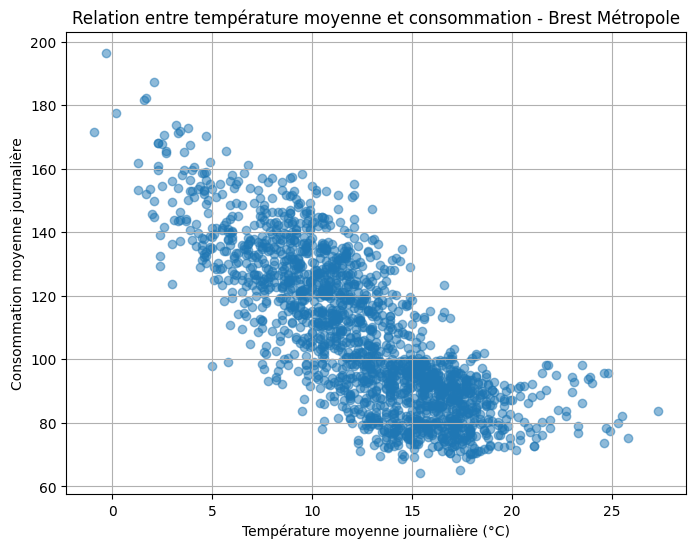

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_train_multivarie["temperature_2m_mean"],
    df_train_multivarie["consommation_moyenne_journaliere"],
    alpha=0.5
)

plt.title("Relation entre température moyenne et consommation - Brest Métropole")
plt.xlabel("Température moyenne journalière (°C)")
plt.ylabel("Consommation moyenne journalière")
plt.grid(True)
plt.show()

### 44.1 Interprétation de la relation entre température et consommation

La visualisation met en évidence une relation décroissante entre la température moyenne journalière et la consommation électrique.

Les journées les plus froides sont souvent associées à des niveaux de consommation plus élevés, tandis que les journées plus douces ou chaudes présentent généralement une consommation plus faible.

Cette relation confirme l'intérêt d'intégrer la température comme variable explicative dans l'approche multivariée.

## 45. Corrélation entre météo et consommation

Calcul des corrélations entre la consommation moyenne journalière et les variables météo.

Cette étape permet de quantifier les relations observées visuellement, notamment entre la température moyenne et la consommation électrique.

In [55]:
# Sélection des colonnes numériques utiles pour l'analyse de corrélation
colonnes_correlation = [
    "consommation_moyenne_journaliere",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_mean"
]

# Calcul de la matrice de corrélation
matrice_correlation = df_train_multivarie[colonnes_correlation].corr()

display(matrice_correlation)

# Corrélation des variables météo avec la consommation
correlation_consommation = (
    matrice_correlation["consommation_moyenne_journaliere"]
    .drop("consommation_moyenne_journaliere")
    .sort_values()
)

display(correlation_consommation)

,consommation_moyenne_journaliere,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean
consommation_moyenne_journaliere,1.000000,-0.791880,-0.733243,-0.789490,0.120344,0.189820
temperature_2m_mean,-0.791880,1.000000,0.958983,0.956647,0.000018,-0.029267
temperature_2m_min,-0.733243,0.958983,1.000000,0.850529,0.084952,0.093716
temperature_2m_max,-0.789490,0.956647,0.850529,1.000000,-0.100897,-0.163238
precipitation_sum,0.120344,0.000018,0.084952,-0.100897,1.000000,0.530816
wind_speed_10m_mean,0.189820,-0.029267,0.093716,-0.163238,0.530816,1.000000


temperature_2m_mean   -0.791880
temperature_2m_max    -0.789490
temperature_2m_min    -0.733243
precipitation_sum      0.120344
wind_speed_10m_mean    0.189820
Name: consommation_moyenne_journaliere, dtype: float64

### 45.1 Interprétation des corrélations météo-consommation

Les corrélations montrent une relation négative forte entre les températures et la consommation électrique.

La température moyenne journalière présente une corrélation d'environ -0,79 avec la consommation. Cela signifie que les journées les plus froides sont généralement associées à des consommations plus élevées, tandis que les journées plus douces sont associées à des consommations plus faibles.

Les variables de température apparaissent donc comme des variables explicatives importantes pour l'approche multivariée.

Les précipitations et le vent présentent des corrélations plus faibles avec la consommation. Elles peuvent être conservées dans un premier modèle multivarié, mais leur influence directe semble moins importante que celle de la température.

## 46. Préparation des variables pour l'approche multivariée

Définition des variables explicatives utilisées pour le premier modèle multivarié.

Les variables sélectionnées combinent les données météo et les informations calendaires.

In [56]:
# Définition de la cible
cible = "consommation_moyenne_journaliere"

# Définition des variables explicatives
variables_explicatives = [
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_mean",
    "jour_semaine_num",
    "mois",
    "est_weekend",
    "est_jour_ferie"
]

# Création des jeux d'entraînement et de test
X_train = df_train_multivarie[variables_explicatives]
y_train_multivarie = df_train_multivarie[cible]

X_test = df_test_multivarie[variables_explicatives]
y_test_multivarie = df_test_multivarie[cible]

print("X_train :", X_train.shape)
print("y_train :", y_train_multivarie.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_multivarie.shape)

display(X_train.head())

X_train : (1826, 9)
y_train : (1826,)
X_test : (150, 9)
y_test : (150,)


,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie
0,2.4,0.5,4.9,2.4,8.4,4,1,0,1
1,4.6,1.5,7.2,2.4,11.9,5,1,1,0
2,3.4,1.9,4.8,3.9,14.6,6,1,1,0
3,3.4,1.2,6.0,1.7,12.2,0,1,0,0
4,3.8,3.0,5.1,2.5,14.2,1,1,0,0


## 47. Modèle multivarié — Random Forest Regressor

Construction d'un premier modèle multivarié avec Random Forest Regressor.

Le modèle utilise les variables météo et calendaires pour prédire la consommation moyenne journalière.

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Initialisation du modèle Random Forest
modele_random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Entraînement du modèle sur les variables météo et calendaires
modele_random_forest.fit(X_train, y_train_multivarie)

print("Modèle Random Forest entraîné.")

Modèle Random Forest entraîné.


## 48. Évaluation du modèle multivarié — Random Forest Regressor

Évaluation du modèle Random Forest Regressor sur le jeu de test.

Les prédictions sont comparées aux valeurs réelles avec les mêmes métriques que les modèles précédents : MAE, RMSE et MAPE.

In [58]:
# Prédiction sur le jeu de test
y_pred_random_forest = modele_random_forest.predict(X_test)

# Création d'une série des valeurs réelles avec un index temporel
y_test_multivarie_indexe = pd.Series(
    y_test_multivarie.values,
    index=df_test_multivarie["date_jour"]
)

# Création d'une série des prédictions avec le même index temporel
y_pred_random_forest = pd.Series(
    y_pred_random_forest,
    index=df_test_multivarie["date_jour"]
)

# Évaluation du modèle
resultats_random_forest = evaluer_modele(
    y_true=y_test_multivarie_indexe,
    y_pred=y_pred_random_forest,
    nom_modele="Random Forest Regressor"
)

resultats_random_forest

{'modele': 'Random Forest Regressor',
 'MAE': 6.49,
 'RMSE': 8.44,
 'MAPE (%)': 5.79}

### 48.1 Visualisation des prédictions du modèle multivarié — Random Forest Regressor

Comparaison visuelle entre les valeurs réelles du jeu de test et les prédictions du modèle Random Forest Regressor.

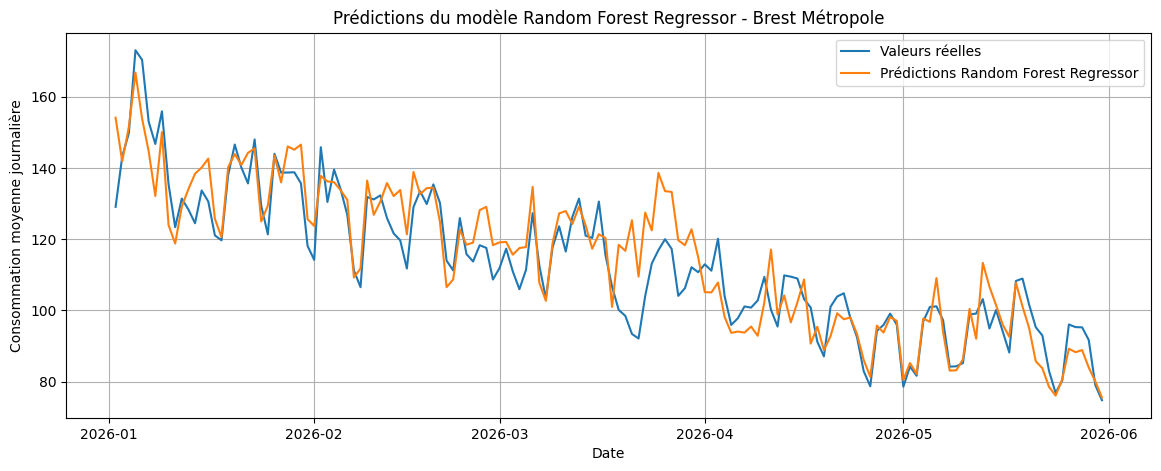

In [59]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test_multivarie_indexe.index,
    y_test_multivarie_indexe,
    label="Valeurs réelles"
)

plt.plot(
    y_pred_random_forest.index,
    y_pred_random_forest,
    label="Prédictions Random Forest Regressor"
)

plt.title("Prédictions du modèle Random Forest Regressor - Brest Métropole")
plt.xlabel("Date")
plt.ylabel("Consommation moyenne journalière")
plt.legend()
plt.grid(True)
plt.show()

### 48.2 Interprétation du modèle multivarié — Random Forest Regressor

Le modèle Random Forest Regressor obtient de meilleures performances que la baseline Seasonal Naive Forecast et que les modèles classiques univariés testés précédemment.

La visualisation montre que les prédictions suivent globalement l'évolution réelle de la consommation sur la période de test. Le modèle reproduit mieux la baisse progressive observée entre janvier et mai 2026, ainsi qu'une partie des variations journalières.

Cette amélioration indique que l'ajout de variables externes, notamment les données météo et les informations calendaires, apporte une information utile pour la prédiction de la consommation électrique.

Ce résultat confirme l'intérêt de comparer une approche univariée, basée uniquement sur l'historique de consommation, avec une approche multivariée intégrant des facteurs explicatifs.

Dans cette première évaluation, les variables météo du jeu de test correspondent à des données historiques. Pour une utilisation opérationnelle à J+1 ou J+3, ces variables devraient être remplacées par des prévisions météo disponibles au moment de la prédiction.

## 49. Comparaison entre approche univariée et approche multivariée

Ajout du modèle Random Forest Regressor au tableau comparatif des performances.

Cette comparaison permet d'évaluer l'apport des variables météo et calendaires par rapport aux modèles basés uniquement sur l'historique de consommation.

In [60]:
# Regroupement des résultats univariés et multivariés
resultats_modeles_complets = [
    resultats_baseline,
    resultats_arima_111,
    resultats_auto_arima,
    resultats_sarima,
    resultats_tbats,
    resultats_random_forest
]

df_comparaison_globale = pd.DataFrame(resultats_modeles_complets)

# Nettoyage des types numériques pour un affichage lisible
colonnes_scores = ["MAE", "RMSE", "MAPE (%)"]

for colonne in colonnes_scores:
    df_comparaison_globale[colonne] = df_comparaison_globale[colonne].astype(float)

# Tri du meilleur au moins bon selon la MAPE
df_comparaison_globale = (
    df_comparaison_globale
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

# Renommage pour l'affichage
df_comparaison_globale_affichage = df_comparaison_globale.rename(columns={
    "modele": "Modèle"
})

# Ajout du rang
df_comparaison_globale_affichage.insert(
    0,
    "Rang",
    range(1, len(df_comparaison_globale_affichage) + 1)
)

# Affichage stylisé
display(
    df_comparaison_globale_affichage.style
    .hide(axis="index")
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE (%)": "{:.2f}"
    })
    .background_gradient(
        subset=["MAE", "RMSE", "MAPE (%)"],
        cmap="RdYlGn_r"
    )
)

# Export du tableau comparatif global
chemin_comparaison_globale = Path("../models/comparaison_globale_modeles.csv")
df_comparaison_globale_affichage.to_csv(chemin_comparaison_globale, index=False)

print("Tableau comparatif global sauvegardé :", chemin_comparaison_globale)

Rang,Modèle,MAE,RMSE,MAPE (%)
1,Random Forest Regressor,6.49,8.44,5.79
2,Seasonal Naive Forecast (J-7),9.35,12.34,8.30
3,"ARIMA(1, 1, 1)",34.74,39.01,34.33
4,"auto-ARIMA(5, 1, 3)",44.96,48.72,43.79
5,"SARIMA(2, 1, 2)(1, 0, 1, 7)",66.24,74.32,65.16
6,TBATS,75.74,83.68,74.07


Tableau comparatif global sauvegardé : ../models/comparaison_globale_modeles.csv


### 49.1 Interprétation de la comparaison univariée / multivariée

Le tableau comparatif montre que le modèle Random Forest Regressor obtient les meilleurs résultats parmi les modèles testés.

Il améliore les performances de la baseline Seasonal Naive Forecast, qui était jusque-là le meilleur modèle de référence univarié.

Cette amélioration indique que les variables météo et calendaires apportent une information utile pour prédire la consommation électrique moyenne journalière.

Les modèles classiques univariés ARIMA, auto-ARIMA, SARIMA et TBATS restent nettement moins performants sur cette période de test. Ils ne parviennent pas à mieux capturer la dynamique de consommation que la baseline hebdomadaire.

À ce stade du projet, l'approche multivariée apparaît donc plus pertinente que l'approche univariée seule.

Il faut toutefois noter que les variables météo utilisées dans cette première évaluation correspondent à des données historiques. Pour une prédiction opérationnelle à J+1 ou J+3, il faudrait utiliser des prévisions météo disponibles au moment de la prédiction.

### 49.2 Sauvegarde du modèle multivarié

Sauvegarde du modèle Random Forest Regressor au format `.pkl`.

Ce modèle est actuellement le plus performant parmi les modèles testés. Il est donc sauvegardé afin de pouvoir être rechargé ultérieurement sans relancer son entraînement.

In [61]:
import pickle
from pathlib import Path

dossier_modeles = Path("../models")
dossier_modeles.mkdir(parents=True, exist_ok=True)

chemin_random_forest = dossier_modeles / "random_forest_regressor.pkl"

with open(chemin_random_forest, "wb") as fichier:
    pickle.dump(modele_random_forest, fichier)

print("Modèle Random Forest sauvegardé :", chemin_random_forest)

Modèle Random Forest sauvegardé : ../models/random_forest_regressor.pkl


### 49.3 Visualisation comparative des performances globales

Visualisation de la MAPE des différents modèles testés.

Ce graphique permet de comparer rapidement les performances des modèles univariés classiques et du modèle multivarié.

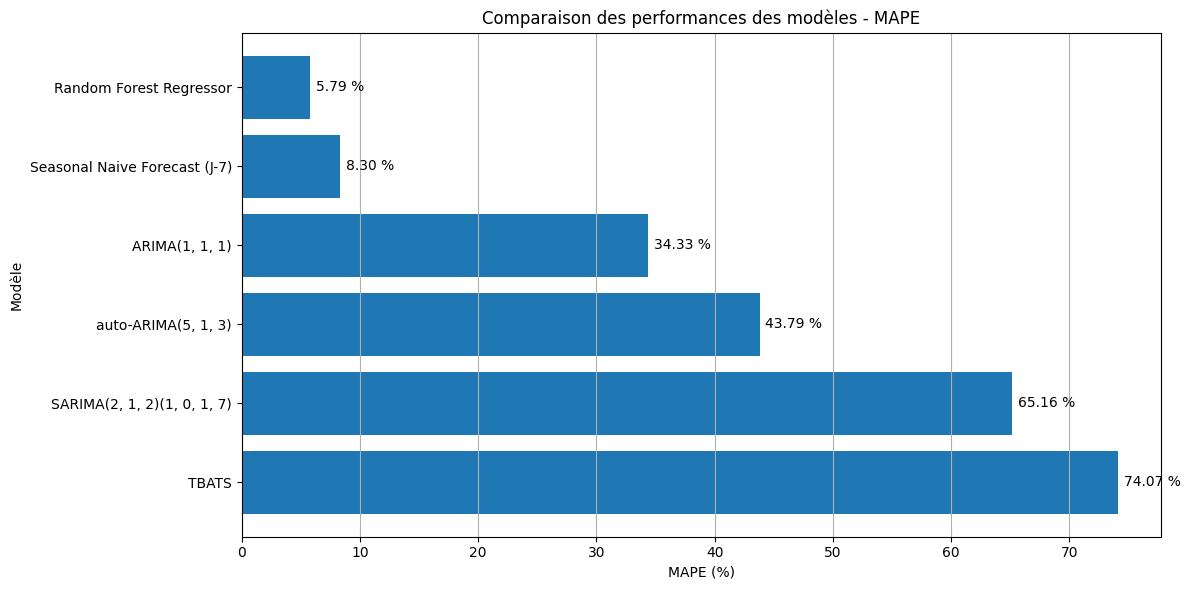

Graphique sauvegardé : ../models/comparaison_mape_modeles.png


In [62]:
from pathlib import Path

# Préparation des données pour le graphique
df_mape_globale = df_comparaison_globale_affichage.copy()
df_mape_globale = df_mape_globale.sort_values("MAPE (%)").reset_index(drop=True)

plt.figure(figsize=(12, 6))

barres = plt.barh(
    df_mape_globale["Modèle"],
    df_mape_globale["MAPE (%)"]
)

plt.xlabel("MAPE (%)")
plt.ylabel("Modèle")
plt.title("Comparaison des performances des modèles - MAPE")
plt.gca().invert_yaxis()
plt.grid(axis="x")

# Affichage des valeurs sur les barres
for barre in barres:
    largeur = barre.get_width()
    plt.text(
        largeur + 0.5,
        barre.get_y() + barre.get_height() / 2,
        f"{largeur:.2f} %",
        va="center"
    )

plt.tight_layout()

# Sauvegarde du graphique pour la présentation
dossier_modeles = Path("../models")
dossier_modeles.mkdir(parents=True, exist_ok=True)

chemin_graphique_mape = dossier_modeles / "comparaison_mape_modeles.png"
plt.savefig(chemin_graphique_mape, dpi=300, bbox_inches="tight")

plt.show()

print("Graphique sauvegardé :", chemin_graphique_mape)

## 50. Préparation des jeux de données pour les horizons J+1 et J+3

Préparation de jeux de données dédiés aux prédictions à J+1 et J+3.

Pour chaque date cible, des variables de consommation passée sont ajoutées afin de simuler les informations disponibles avant la prédiction.

Les lignes pour lesquelles les variables de consommation passée ne sont pas disponibles sont supprimées. Cela concerne notamment certaines dates proches du début du jeu de test, car le 1er janvier 2026 a été exclu du jeu d'évaluation en raison de l'anomalie de donnée source identifiée précédemment.

Dans cette évaluation rétrospective, les variables météo correspondent aux données observées du jour cible. Dans un usage opérationnel, elles devraient être remplacées par des prévisions météo disponibles au moment de la prédiction.

In [63]:
def creer_jeu_horizon(df_cible, df_source_lags, horizon):
    df = df_cible.copy()

    # Consommation connue à J-horizon
    source_horizon = df_source_lags[[
        "date_jour",
        "consommation_moyenne_journaliere"
    ]].copy()

    source_horizon["date_jour"] = (
        source_horizon["date_jour"] + pd.Timedelta(days=horizon)
    )

    source_horizon = source_horizon.rename(columns={
        "consommation_moyenne_journaliere": f"consommation_j_moins_{horizon}"
    })

    df = df.merge(
        source_horizon,
        on="date_jour",
        how="left"
    )

    # Consommation connue une semaine avant
    source_j_7 = df_source_lags[[
        "date_jour",
        "consommation_moyenne_journaliere"
    ]].copy()

    source_j_7["date_jour"] = (
        source_j_7["date_jour"] + pd.Timedelta(days=7)
    )

    source_j_7 = source_j_7.rename(columns={
        "consommation_moyenne_journaliere": "consommation_j_moins_7"
    })

    df = df.merge(
        source_j_7,
        on="date_jour",
        how="left"
    )

    # Suppression des lignes pour lesquelles les variables de décalage ne sont pas disponibles
    df = df.dropna(subset=[
        f"consommation_j_moins_{horizon}",
        "consommation_j_moins_7"
    ]).reset_index(drop=True)

    return df


# Source des consommations passées pour l'entraînement
df_source_lags_train = df_train_multivarie[[
    "date_jour",
    "consommation_moyenne_journaliere"
]].copy()

# Source des consommations passées pour le test
# Elle combine le train et le test d'évaluation afin de simuler une évaluation temporelle.
df_source_lags_complet = pd.concat(
    [
        df_train_multivarie[["date_jour", "consommation_moyenne_journaliere"]],
        df_test_multivarie[["date_jour", "consommation_moyenne_journaliere"]]
    ],
    ignore_index=True
).sort_values("date_jour").reset_index(drop=True)


df_train_j1 = creer_jeu_horizon(
    df_train_multivarie,
    df_source_lags_train,
    horizon=1
)

df_test_j1 = creer_jeu_horizon(
    df_test_multivarie,
    df_source_lags_complet,
    horizon=1
)

df_train_j3 = creer_jeu_horizon(
    df_train_multivarie,
    df_source_lags_train,
    horizon=3
)

df_test_j3 = creer_jeu_horizon(
    df_test_multivarie,
    df_source_lags_complet,
    horizon=3
)

print("Train J+1 :", df_train_j1.shape)
print("Test J+1 :", df_test_j1.shape)
print("Train J+3 :", df_train_j3.shape)
print("Test J+3 :", df_test_j3.shape)

display(df_test_j1.head())
display(df_test_j3.head())

Train J+1 : (1819, 15)
Test J+1 : (148, 15)
Train J+3 : (1819, 15)
Test J+3 : (148, 15)


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie,saison,consommation_j_moins_1,consommation_j_moins_7
0,2026-01-03,143.187500,96,4.6,2.5,6.8,0.0,8.8,5,1,1,0,hiver,129.083333,153.083333
1,2026-01-04,149.760417,96,2.6,0.9,5.4,0.2,4.9,6,1,1,0,hiver,143.187500,143.697917
2,2026-01-05,173.052083,96,3.6,1.2,5.6,8.6,13.5,0,1,0,0,hiver,149.760417,153.114583
3,2026-01-06,170.364583,96,4.1,-0.1,7.8,0.0,10.4,1,1,0,0,hiver,173.052083,157.885417
4,2026-01-07,152.968750,96,8.6,7.0,11.4,11.0,21.9,2,1,0,0,hiver,170.364583,159.489583


,date_jour,consommation_moyenne_journaliere,nb_mesures_jour,temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum,wind_speed_10m_mean,jour_semaine_num,mois,est_weekend,est_jour_ferie,saison,consommation_j_moins_3,consommation_j_moins_7
0,2026-01-02,129.083333,96,5.8,4.2,8.9,0.0,9.6,4,1,0,0,hiver,157.885417,160.781250
1,2026-01-03,143.187500,96,4.6,2.5,6.8,0.0,8.8,5,1,1,0,hiver,159.489583,153.083333
2,2026-01-05,173.052083,96,3.6,1.2,5.6,8.6,13.5,0,1,0,0,hiver,129.083333,153.114583
3,2026-01-06,170.364583,96,4.1,-0.1,7.8,0.0,10.4,1,1,0,0,hiver,143.187500,157.885417
4,2026-01-07,152.968750,96,8.6,7.0,11.4,11.0,21.9,2,1,0,0,hiver,149.760417,159.489583


## 51. Modèles multivariés pour les horizons J+1 et J+3

Entraînement de deux modèles Random Forest Regressor dédiés aux horizons de prédiction J+1 et J+3.

Chaque modèle utilise les variables météo, les variables calendaires et des informations de consommation passée disponibles avant l'horizon de prédiction.

In [64]:
def entrainer_evaluer_random_forest_horizon(df_train_horizon, df_test_horizon, horizon):
    variable_lag_horizon = f"consommation_j_moins_{horizon}"

    variables_horizon = variables_explicatives + [
        variable_lag_horizon,
        "consommation_j_moins_7"
    ]

    X_train_horizon = df_train_horizon[variables_horizon]
    y_train_horizon = df_train_horizon[cible]

    X_test_horizon = df_test_horizon[variables_horizon]

    y_test_horizon = pd.Series(
        df_test_horizon[cible].values,
        index=df_test_horizon["date_jour"]
    )

    modele = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    modele.fit(X_train_horizon, y_train_horizon)

    y_pred_horizon = pd.Series(
        modele.predict(X_test_horizon),
        index=df_test_horizon["date_jour"]
    )

    resultats = evaluer_modele(
        y_true=y_test_horizon,
        y_pred=y_pred_horizon,
        nom_modele=f"Random Forest Regressor — J+{horizon}"
    )

    return modele, y_test_horizon, y_pred_horizon, resultats


modele_random_forest_j1, y_test_j1, y_pred_random_forest_j1, resultats_random_forest_j1 = (
    entrainer_evaluer_random_forest_horizon(
        df_train_j1,
        df_test_j1,
        horizon=1
    )
)

modele_random_forest_j3, y_test_j3, y_pred_random_forest_j3, resultats_random_forest_j3 = (
    entrainer_evaluer_random_forest_horizon(
        df_train_j3,
        df_test_j3,
        horizon=3
    )
)

print("Résultats Random Forest J+1")
print(resultats_random_forest_j1)

print("\nRésultats Random Forest J+3")
print(resultats_random_forest_j3)

Résultats Random Forest J+1
{'modele': 'Random Forest Regressor — J+1', 'MAE': 3.98, 'RMSE': 5.03, 'MAPE (%)': 3.49}

Résultats Random Forest J+3
{'modele': 'Random Forest Regressor — J+3', 'MAE': 5.04, 'RMSE': 6.54, 'MAPE (%)': 4.45}


## 52. Comparaison des performances aux horizons J+1 et J+3

Comparaison des performances du modèle Random Forest Regressor pour les horizons de prédiction J+1 et J+3.

Cette étape permet d'observer l'évolution des erreurs lorsque l'horizon de prédiction s'allonge.

In [65]:
df_comparaison_horizons = pd.DataFrame([
    resultats_random_forest,
    resultats_random_forest_j1,
    resultats_random_forest_j3
])

for colonne in ["MAE", "RMSE", "MAPE (%)"]:
    df_comparaison_horizons[colonne] = df_comparaison_horizons[colonne].astype(float)

df_comparaison_horizons = (
    df_comparaison_horizons
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

df_comparaison_horizons_affichage = df_comparaison_horizons.rename(columns={
    "modele": "Modèle"
})

display(
    df_comparaison_horizons_affichage.style
    .hide(axis="index")
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE (%)": "{:.2f}"
    })
    .background_gradient(
        subset=["MAE", "RMSE", "MAPE (%)"],
        cmap="RdYlGn_r"
    )
)

chemin_comparaison_horizons = Path("../models/comparaison_horizons_j1_j3.csv")
df_comparaison_horizons_affichage.to_csv(chemin_comparaison_horizons, index=False)

print("Tableau de comparaison des horizons sauvegardé :", chemin_comparaison_horizons)

Modèle,MAE,RMSE,MAPE (%)
Random Forest Regressor — J+1,3.98,5.03,3.49
Random Forest Regressor — J+3,5.04,6.54,4.45
Random Forest Regressor,6.49,8.44,5.79


Tableau de comparaison des horizons sauvegardé : ../models/comparaison_horizons_j1_j3.csv


### 52.1 Interprétation des horizons J+1 et J+3

Les modèles Random Forest Regressor dédiés aux horizons J+1 et J+3 permettent d'évaluer la capacité du modèle à prédire la consommation à différents horizons temporels.

Ces modèles utilisent les variables météo, les variables calendaires et des informations de consommation passée disponibles avant l'horizon de prédiction.

Les résultats montrent que l'ajout de variables de consommation décalées améliore les performances par rapport au premier modèle multivarié, qui utilisait uniquement la météo et le calendrier.

La comparaison entre J+1 et J+3 montre également que l'allongement de l'horizon de prédiction tend à dégrader les performances, ce qui est cohérent : plus la date à prédire est éloignée, plus la prédiction devient difficile.

Ces résultats doivent toutefois être interprétés avec prudence. Dans cette évaluation rétrospective, les variables météo utilisées sur la période de test correspondent à des données historiques. Dans un usage opérationnel, elles devraient être remplacées par des prévisions météo disponibles au moment de la prédiction.

### 52.2 Sauvegarde des modèles J+1 et J+3

Sauvegarde des modèles Random Forest Regressor dédiés aux horizons J+1 et J+3 au format `.pkl`.

Ces modèles peuvent ainsi être rechargés ultérieurement sans relancer leur entraînement.

In [66]:
modeles_horizons_a_sauvegarder = {
    "random_forest_j1.pkl": modele_random_forest_j1,
    "random_forest_j3.pkl": modele_random_forest_j3
}

for nom_fichier, modele in modeles_horizons_a_sauvegarder.items():
    chemin_modele = Path("../models") / nom_fichier

    with open(chemin_modele, "wb") as fichier:
        pickle.dump(modele, fichier)

    print("Modèle sauvegardé :", chemin_modele)

Modèle sauvegardé : ../models/random_forest_j1.pkl
Modèle sauvegardé : ../models/random_forest_j3.pkl


### 52.3 Visualisation des performances aux horizons J+1 et J+3

Visualisation de la MAPE des modèles Random Forest Regressor selon l'horizon de prédiction.

Ce graphique permet d'observer l'évolution des performances entre l'évaluation multivariée initiale, l'horizon J+1 et l'horizon J+3.

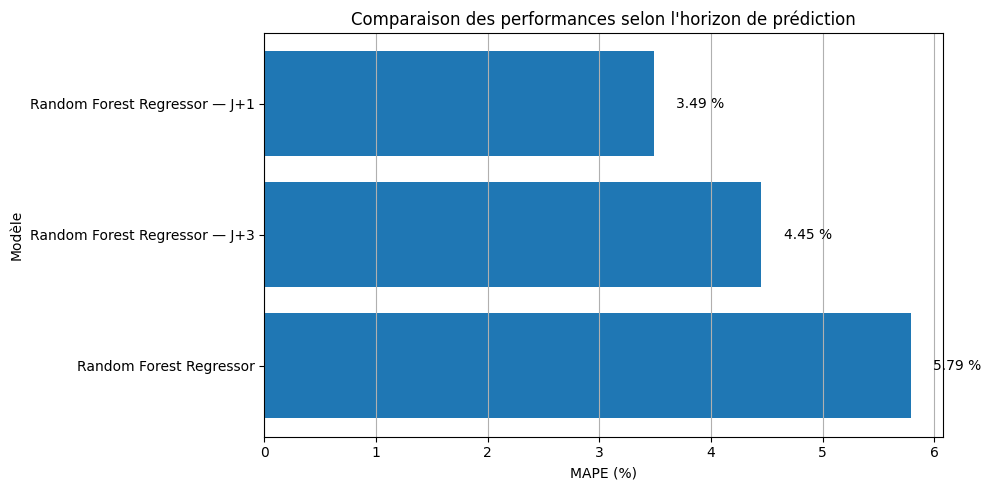

Graphique sauvegardé : ../models/comparaison_horizons_j1_j3.png


In [67]:
# Préparation des données pour le graphique des horizons
df_mape_horizons = df_comparaison_horizons_affichage.copy()
df_mape_horizons = df_mape_horizons.sort_values("MAPE (%)").reset_index(drop=True)

plt.figure(figsize=(10, 5))

barres = plt.barh(
    df_mape_horizons["Modèle"],
    df_mape_horizons["MAPE (%)"]
)

plt.xlabel("MAPE (%)")
plt.ylabel("Modèle")
plt.title("Comparaison des performances selon l'horizon de prédiction")
plt.gca().invert_yaxis()
plt.grid(axis="x")

# Affichage des valeurs sur les barres
for barre in barres:
    largeur = barre.get_width()
    plt.text(
        largeur + 0.2,
        barre.get_y() + barre.get_height() / 2,
        f"{largeur:.2f} %",
        va="center"
    )

plt.tight_layout()

# Sauvegarde du graphique pour la présentation
chemin_graphique_horizons = Path("../models/comparaison_horizons_j1_j3.png")
plt.savefig(chemin_graphique_horizons, dpi=300, bbox_inches="tight")

plt.show()

print("Graphique sauvegardé :", chemin_graphique_horizons)

## 53. Schéma de synthèse de la démarche projet

Visualisation synthétique de la démarche suivie dans le notebook.

Ce schéma présente les principales sources de données, la construction du dataset journalier, les approches de modélisation testées et les métriques utilisées pour comparer les résultats.

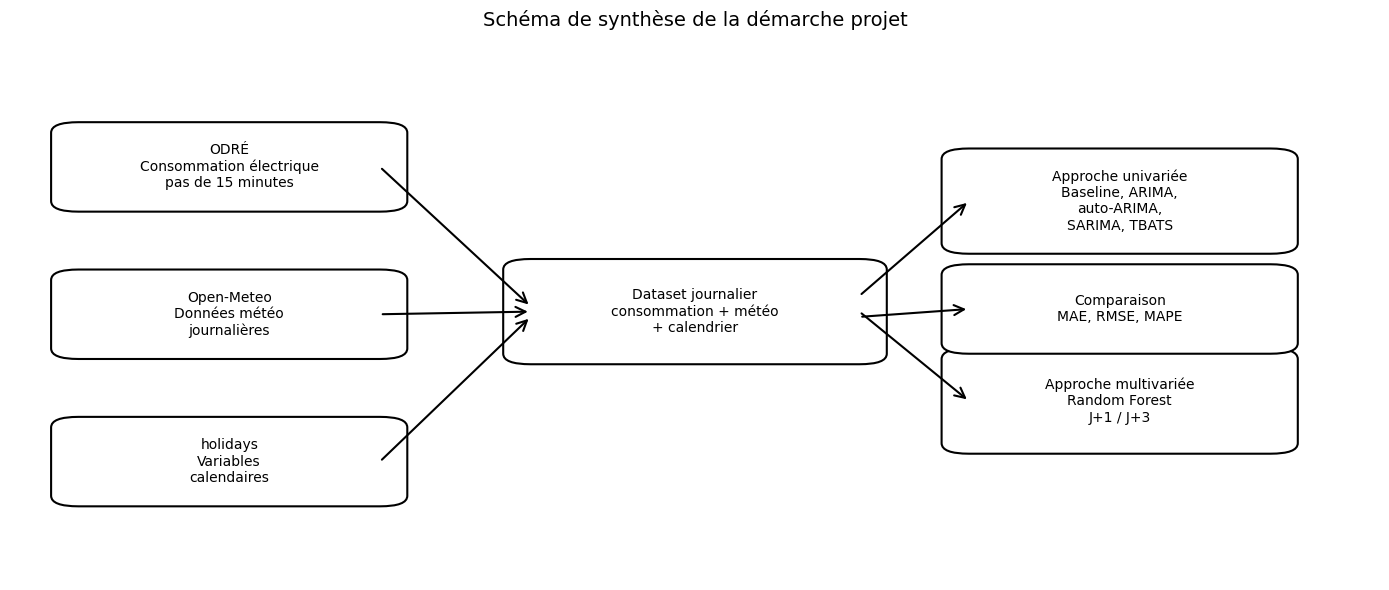

Schéma sauvegardé : ../models/schema_pipeline_projet.png


In [68]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 6))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def ajouter_boite(x, y, texte, largeur=0.22, hauteur=0.13):
    boite = FancyBboxPatch(
        (x, y),
        largeur,
        hauteur,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(boite)

    ax.text(
        x + largeur / 2,
        y + hauteur / 2,
        texte,
        ha="center",
        va="center",
        fontsize=10
    )

def ajouter_fleche(x1, y1, x2, y2):
    fleche = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.5
    )
    ax.add_patch(fleche)

# Sources de données
ajouter_boite(
    0.05,
    0.72,
    "ODRÉ\nConsommation électrique\npas de 15 minutes"
)

ajouter_boite(
    0.05,
    0.44,
    "Open-Meteo\nDonnées météo\njournalières"
)

ajouter_boite(
    0.05,
    0.16,
    "holidays\nVariables\ncalendaires"
)

# Dataset central
ajouter_boite(
    0.38,
    0.43,
    "Dataset journalier\nconsommation + météo\n+ calendrier",
    largeur=0.24,
    hauteur=0.16
)

# Approches de modélisation
ajouter_boite(
    0.70,
    0.64,
    "Approche univariée\nBaseline, ARIMA,\nauto-ARIMA,\nSARIMA, TBATS",
    largeur=0.22,
    hauteur=0.16
)

ajouter_boite(
    0.70,
    0.26,
    "Approche multivariée\nRandom Forest\nJ+1 / J+3",
    largeur=0.22,
    hauteur=0.16
)

# Comparaison finale
ajouter_boite(
    0.70,
    0.45,
    "Comparaison\nMAE, RMSE, MAPE",
    largeur=0.22,
    hauteur=0.13
)

# Flèches vers le dataset
ajouter_fleche(0.27, 0.785, 0.38, 0.52)
ajouter_fleche(0.27, 0.505, 0.38, 0.51)
ajouter_fleche(0.27, 0.225, 0.38, 0.50)

# Flèches vers les modèles
ajouter_fleche(0.62, 0.54, 0.70, 0.72)
ajouter_fleche(0.62, 0.51, 0.70, 0.34)
ajouter_fleche(0.62, 0.50, 0.70, 0.515)

plt.title(
    "Schéma de synthèse de la démarche projet",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# Sauvegarde du schéma pour la présentation
chemin_schema_pipeline = Path("../models/schema_pipeline_projet.png")
plt.savefig(chemin_schema_pipeline, dpi=300, bbox_inches="tight")

plt.show()

print("Schéma sauvegardé :", chemin_schema_pipeline)

## 54. Synthèse provisoire des résultats

Cette première phase du projet a permis de construire une base de travail propre pour la prédiction de consommation électrique de Brest Métropole.

Les données de consommation issues d'ODRÉ ont été récupérées, contrôlées, agrégées à l'échelle journalière, puis séparées en jeu d'entraînement et jeu de test.

Une anomalie de donnée source a été identifiée sur le 1er janvier 2026 : toutes les mesures disponibles pour cette journée étaient égales à zéro. Cette journée a été conservée dans le diagnostic qualité, mais exclue du jeu d'évaluation.

Dans l'approche univariée, la baseline Seasonal Naive Forecast (J-7) obtient les meilleurs résultats parmi les modèles basés uniquement sur l'historique de consommation. Les modèles ARIMA, auto-ARIMA, SARIMA et TBATS testés ne parviennent pas à améliorer cette baseline.

L'enrichissement avec les données météo Open-Meteo et les variables calendaires améliore les performances. Le modèle Random Forest Regressor obtient les meilleurs résultats à ce stade, ce qui confirme l'intérêt d'une approche multivariée.

Des modèles Random Forest dédiés aux horizons J+1 et J+3 ont également été préparés afin de se rapprocher du besoin de prédiction exprimé dans le brief. Ces modèles utilisent des variables de consommation passée en complément des variables météo et calendaires.

Les résultats obtenus doivent toutefois être interprétés avec prudence : dans cette évaluation rétrospective, les variables météo du jeu de test correspondent à des données historiques. Pour une utilisation opérationnelle, elles devraient être remplacées par des prévisions météo disponibles au moment de la prédiction.

La suite du projet pourra approfondir cette approche avec d'autres modèles, des variables supplémentaires et une analyse plus fine de la détection d'anomalies.